#Overview


Silverkite Model is a flexible and interpretable time series forecasting algorithm developed by linkedin as a part of the greykite library. Silverkite model applies to most of the time series as it has various components and many parameters that can be tuned, which makes it suitable to model complex time series patterns. The brief description of various components of the silverkite library can be found below -



1.   **Trend-** This component models the long-term trajectory of a time series, whether the time series will be increasing, decreasing, or stable. It is modeled using a growth term (linear, quadratic, square root or custom), with changepoints to allow shifts in the trends.
2.   **Seasonality-** This component models the recurring/periodic patterns in the time series. It is modeled using Fourier series applied to different periodicity levels, such as yearly, quarterly, monthly, weekly and daily. The model allows auto selection of seasonality as well although it also allow specifying various tunning parameters for better fit.
3.  **Holidays and events-** This component models the impact of holidays and any particular events in the time series. Holidays can be modeled with effects like pre- and post- holiday trends.
4.  **Autoregression -** This component creates features using the autoregressive lags or aggregated lags (for example, moving averages). The lags and the range of lags for aggregation can be specified manually.
5. **Regressors -** Here, any external variable can be included for modeling. Please note that in this case, the user needs to provide the values for both the training and testing periods.
6. **Interaction-** This term includes interactions between the above components.

The model is estimated using regularized regression techniques. Also, in addition to this model, Silverkite library also builds a volatility model, which estimates the forecast uncertainty.





# Installing Prophet and Greykite library

In [ ]:
!pip install prophet==1.1.5 "numpy<2.0" cmdstanpy==1.2.0

  Using cached holidays-0.83-py3-none-any.whl.metadata (50 kB)
Using cached holidays-0.83-py3-none-any.whl (1.3 MB)
  Attempting uninstall: holidays
    Found existing installation: holidays 0.24
    Uninstalling holidays-0.24:
      Successfully uninstalled holidays-0.24
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
greykite 1.1.0 requires holidays==0.13, but you have holidays 0.83 which is incompatible.


In [ ]:
!pip install greykite

  Using cached holidays-0.13-py3-none-any.whl.metadata (11 kB)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 377, in run
    requirement_set = resolver.resolve(
                      ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/resolution/resolvelib/resolver.py", line 95, in resolve
    result = self._result = resolver.resolve(
                            ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_vendor/resolvelib/resolvers.py", line 546, in resolve
    state = resolution.resolve(requirements, max_rou

In [ ]:
! pip install "holidays==0.24.0"



  Using cached holidays-0.24-py3-none-any.whl.metadata (16 kB)
Using cached holidays-0.24-py3-none-any.whl (499 kB)
  Attempting uninstall: holidays
    Found existing installation: holidays 0.83
    Uninstalling holidays-0.83:
      Successfully uninstalled holidays-0.83
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
prophet 1.1.5 requires holidays>=0.25, but you have holidays 0.24 which is incompatible.
greykite 1.1.0 requires holidays==0.13, but you have holidays 0.24 which is incompatible.


# Importing relevant libraries

In [ ]:
from prophet import Prophet
import plotly
import matplotlib
import holidays
import holidays_ext

from greykite.common.data_loader import DataLoader
from greykite.framework.templates.autogen.forecast_config import ForecastConfig
from greykite.framework.templates.autogen.forecast_config import MetadataParam
from greykite.framework.templates.forecaster import Forecaster
from greykite.framework.templates.model_templates import ModelTemplateEnum
from greykite.framework.utils.result_summary import summarize_grid_search_results
from greykite.framework.templates.autogen.forecast_config import ModelComponentsParam
from greykite.algo.forecast.silverkite.constants.silverkite_holiday import SilverkiteHoliday
from greykite.sklearn.cross_validation import RollingTimeSeriesSplit
# from greykite.algo.forecast.silverkite.silverkite_estimator import SilverkiteEstimator
from greykite.framework.templates.autogen.forecast_config import EvaluationPeriodParam
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import numpy as np
import itertools
import pandas as pd
import time
import matplotlib.pyplot as plt
from datetime import datetime
from collections import defaultdict

import warnings
warnings.filterwarnings("ignore")



# Data Preparetion for Silverkite model

In [ ]:
df = pd.read_csv("BTCUSD.csv")

df = df[['Date', 'Close']]
df['Date'] = pd.to_datetime(df['Date'])
#Define the start and end dates for filtering
start_date = pd.to_datetime('2019-04-01')
end_date = pd.to_datetime('2025-04-01')

# Keep only the Date and Close columns, rename 'Close' to 'y' for modeling
#df = df[['Date', 'Close']].rename(columns={'Close': 'y'}).sort_values('Date').reset_index(drop=True)
df = df[(df['Date'] >= start_date) & (df['Date'] <= end_date)]
df = df.rename(columns={"Date":"ts","Close":"y"})
df['y'] = df['y'].astype(float)

train = df.iloc[:-7].reset_index(drop=True)
test = df.iloc[-7:].reset_index(drop=True)



In [ ]:
df.head()

,ts,y
1657,2019-04-01,4158.183105
1658,2019-04-02,4879.877930
1659,2019-04-03,4973.021973
1660,2019-04-04,4922.798828
1661,2019-04-05,5036.681152


In [ ]:
train.tail()

,ts,y
2181,2025-03-21,84043.242188
2182,2025-03-22,83832.484375
2183,2025-03-23,86054.375000
2184,2025-03-24,87498.914062
2185,2025-03-25,87471.703125


In [ ]:
df.head()

,ts,y
1657,2019-04-01,4158.183105
1658,2019-04-02,4879.877930
1659,2019-04-03,4973.021973
1660,2019-04-04,4922.798828
1661,2019-04-05,5036.681152


In [ ]:
df.tail()

,ts,y
3845,2025-03-28,84353.148438
3846,2025-03-29,82597.585938
3847,2025-03-30,82334.523438
3848,2025-03-31,82548.914062
3849,2025-04-01,85169.171875


#Comparing different trends

The brief decription of different types of growth terms can be found below:
* **Linear:** Steady, constant-rate growth or decline (straight line).
* **Quadratic:** Curved trend with accelerating or decelerating growth (parabola).
* **Square Root:** Rapid initial growth slowing over time (modeled using square root term of time t).
* **Automatic (auto_growth=True):** Algorithm selects trend and changepoints based on data.
* **Custom (growth_func):** User-defined function for specialized trends (e.g., exponential). Supports changepoints for trend shifts.

**Experiment Details-**

In the following implementation, we will experiment with linear, quadratic and square root growth terms with fixed changepoint configuration ({"method": "auto", "potential_changepoint_n": 10}) while not considering other components to evaluate the trend term which might fit the time series better.

For comparison of the model performace, metrics like Mean Absolute Percentage Error, Mean Absolute Error, And Precision Error are used.

*Note*: By default, the time 't' is derived from the timestamp column (e.g., "ts") and transformed into a continuous time column, often denoted as "ct1". "ct1" is typically a linear time index scaled to years (e.g., starting from 0 at the first timestamp, with each year incrementing t by 1).

In [ ]:
%matplotlib inline

In [ ]:
# We define here the precision measure
# Other measures available from sklearn.metrics
def calculate_precision_error(actual, forecast):
    """
    Calculate Precision Error (PM): ratio of prediction error to variance of actuals.

    PM = sum((actual - forecast)^2) / sum((actual - mean(actual))^2)

    Args:
        actual: Array of actual values
        forecast: Array of forecasted/predicted values

    Returns:
        Precision Error (PM) value
    """
    actual = np.array(actual)
    forecast = np.array(forecast)
    mean_actual = np.mean(actual)

    numerator = np.sum((actual - forecast) ** 2)
    denominator = np.sum((actual - mean_actual) ** 2)

    if denominator == 0:
        return np.nan  # Avoid divide by zero

    return numerator / denominator


In [ ]:
def calculate_metrics(actual, predicted):
    """
    Calculate MSPE, MAE, MAPE, and PM (precision error) for time series predictions.
    """
    mspe = mean_squared_error(actual, predicted)
    mae = mean_absolute_error(actual, predicted)
    mape = 100 * np.mean(np.abs((actual - predicted) / (actual + 1e-6)))
    pm = np.sum((actual - predicted) ** 2) / np.sum((actual - np.mean(actual)) ** 2)

    return {
        'MSPE': mspe,
        'MAE': mae,
        'MAPE': mape,
        'Precision_error': pm
    }


Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


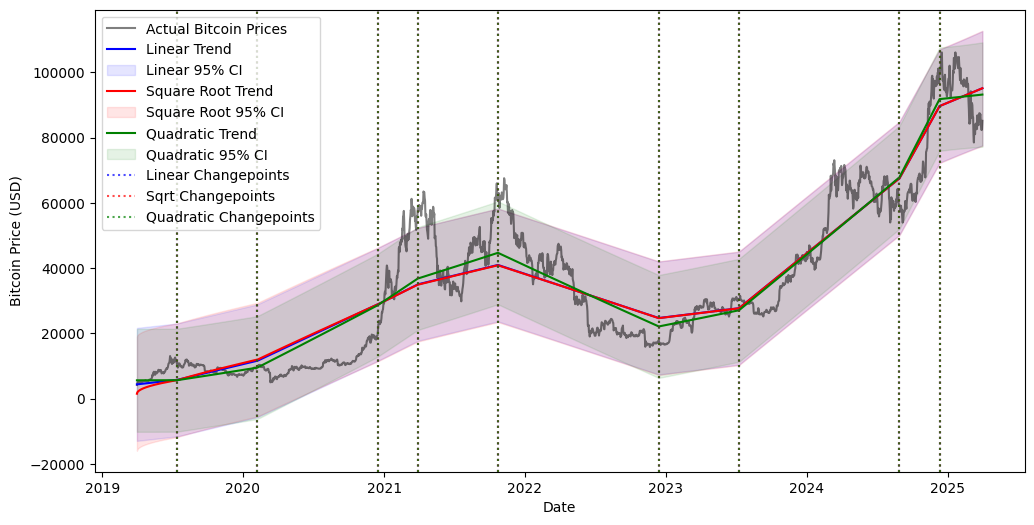

Comparative Metrics:
               Model    MSPE_train    MAE_train  MAPE_train  \
0       Linear Trend  7.762975e+07  6985.146464   30.405283   
1  Square Root Trend  7.873485e+07  7075.738485   31.581659   
2    Quadratic Trend  6.447032e+07  6272.736521   26.368416   

   Precision_Error_train  
0               0.129753  
1               0.131600  
2               0.107758  

Linear Changepoints: [Timestamp('2019-07-14 00:00:00'), Timestamp('2020-02-07 00:00:00'), Timestamp('2020-12-15 00:00:00'), Timestamp('2021-03-29 00:00:00'), Timestamp('2021-10-23 00:00:00'), Timestamp('2022-12-14 00:00:00'), Timestamp('2023-07-10 00:00:00'), Timestamp('2024-08-29 00:00:00'), Timestamp('2024-12-11 00:00:00')]
Square Root Changepoints: [Timestamp('2019-07-14 00:00:00'), Timestamp('2020-02-07 00:00:00'), Timestamp('2020-12-15 00:00:00'), Timestamp('2021-03-29 00:00:00'), Timestamp('2021-10-23 00:00:00'), Timestamp('2022-12-14 00:00:00'), Timestamp('2023-07-10 00:00:00'), Timestamp('2024-08-29 00

In [ ]:
# Silverkite with Linear Trend
linear_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": "linear"},
        changepoints={"changepoints_dict": {"method": "auto", "potential_changepoint_n": 20}},
        seasonality={"yearly_seasonality": False, "quarterly_seasonality": False,
                     "monthly_seasonality": False, "weekly_seasonality": False,
                     "daily_seasonality": False, "auto_seasonality": False},
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)
forecaster = Forecaster()
## Prediction of last week of bitcoin data
linear_result = forecaster.run_forecast_config(df=train, config=linear_config)
## Fitting the trend using the test data
linear_forecast_df = linear_result.forecast.df
linear_changepoints = linear_result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])

# --- Silverkite with Square Root Trend ---
sqrt_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": "sqrt"},
        changepoints={"changepoints_dict": {"method": "auto", "potential_changepoint_n": 20}},
        seasonality={"yearly_seasonality": False, "quarterly_seasonality": False,
                     "monthly_seasonality": False, "weekly_seasonality": False,
                     "daily_seasonality": False, "auto_seasonality": False},
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)
## Prediction of last week of bitcoin data
sqrt_result = forecaster.run_forecast_config(df=train, config=sqrt_config)
# Fitting the trend using the test data
sqrt_forecast_df = sqrt_result.forecast.df
sqrt_changepoints = sqrt_result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])

# Silverkite with Quadratic Trend
quadratic_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": "quadratic"},
        changepoints={"changepoints_dict": {"method": "auto", "potential_changepoint_n": 20}},
        seasonality={"yearly_seasonality": False, "quarterly_seasonality": False,
                     "monthly_seasonality": False, "weekly_seasonality": False,
                     "daily_seasonality": False, "auto_seasonality": False},
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)
## Prediction of last week of bitcoin data
quadratic_result = forecaster.run_forecast_config(df=train, config=quadratic_config)
# Fitting the trend using the test data
quadratic_forecast_df = quadratic_result.forecast.df
quadratic_changepoints = quadratic_result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])

# Plotting Comparison on Train Data: How well each model fits the trend only?
plt.figure(figsize=(12, 6))
plt.plot(df['ts'], df['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Linear Trend Model
plt.plot(linear_forecast_df['ts'], linear_forecast_df['forecast'], label='Linear Trend', color='blue')
plt.fill_between(linear_forecast_df['ts'], linear_forecast_df['forecast_lower'], linear_forecast_df['forecast_upper'],
                 color='blue', alpha=0.1, label='Linear 95% CI')
# Square Root Trend Model
plt.plot(sqrt_forecast_df['ts'], sqrt_forecast_df['forecast'], label='Square Root Trend', color='red')
plt.fill_between(sqrt_forecast_df['ts'], sqrt_forecast_df['forecast_lower'], sqrt_forecast_df['forecast_upper'],
                 color='red', alpha=0.1, label='Square Root 95% CI')
# Quadratic Trend Model
plt.plot(quadratic_forecast_df['ts'], quadratic_forecast_df['forecast'], label='Quadratic Trend', color='green')
plt.fill_between(quadratic_forecast_df['ts'], quadratic_forecast_df['forecast_lower'], quadratic_forecast_df['forecast_upper'],
                 color='green', alpha=0.1, label='Quadratic 95% CI')

# Add the lines corresponding to the changepoints
for cp in linear_changepoints:
    plt.axvline(x=cp, color='blue', linestyle=':', alpha=0.7,
                label='Linear Changepoints' if cp == linear_changepoints[0] else "")
for cp in sqrt_changepoints:
    plt.axvline(x=cp, color='red', linestyle=':', alpha=0.7,
                label='Sqrt Changepoints' if cp == sqrt_changepoints[0] else "")
for cp in quadratic_changepoints:
    plt.axvline(x=cp, color='green', linestyle=':', alpha=0.7,
                label='Quadratic Changepoints' if cp == quadratic_changepoints[0] else "")

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.legend()
plt.show()

# Merge actual values with forecast DataFrames
linear_forecast_df = linear_forecast_df.merge(df[['ts', 'y']], on='ts', how='left')
sqrt_forecast_df = sqrt_forecast_df.merge(df[['ts', 'y']], on='ts', how='left')
quadratic_forecast_df = quadratic_forecast_df.merge(df[['ts', 'y']], on='ts', how='left')

# Identify train and test periods in the forecast DataFrames
test_start = test['ts'].iloc[0]
train_period = linear_forecast_df['ts'] < test_start
test_period = linear_forecast_df['ts'] >= test_start

# Calculate Fit Accuracy Measures for Each Model using the Train Data
model_names = ['Linear Trend', 'Square Root Trend', 'Quadratic Trend']
model_forecasts = [linear_forecast_df, sqrt_forecast_df, quadratic_forecast_df]
model_dicts = []
# Apply the 'calculate_metrics' function
# for model_name, forecast_df in zip(model_names, model_forecasts):
#     metrics = calculate_metrics(forecast_df.loc[train_period, 'y'], forecast_df.loc[train_period, 'forecast'])
#     model_dict = {"Model":model_name}
#     model_dict['MAPE_train'] = metrics['MAPE']
#     model_dict['MAE_train'] = metrics['MAE']
#     #model_dict['Precision_Error_train'] = metrics['Precision_eror']
#     model_dicts.append(model_dict)
# metrics_df = pd.DataFrame(model_dicts)

for model_name, forecast_df in zip(model_names, model_forecasts):
    metrics = calculate_metrics(
        forecast_df.loc[train_period, 'y'],
        forecast_df.loc[train_period, 'forecast']
    )

    model_dict = {"Model": model_name}
    model_dict['MSPE_train'] = metrics['MSPE']
    model_dict['MAE_train'] = metrics['MAE']
    model_dict['MAPE_train'] = metrics['MAPE']
    model_dict['Precision_Error_train'] = metrics['Precision_error']

    model_dicts.append(model_dict)

metrics_df = pd.DataFrame(model_dicts)
# Display Results
print("Comparative Metrics:")
print(metrics_df)
print("\nLinear Changepoints:", linear_changepoints)
print("Square Root Changepoints:", sqrt_changepoints)
print("Quadratic Changepoints:", quadratic_changepoints)

**Insights from this analysis**: The table above shows the accuracy measure values on the train data. As can be seen, the *quadratic* trend is relatively better in terms of MAPE value of 26.36 on the train set.

Next, we also provide the plot contrasting the predictions and the metrics applied to the test data,  that is, for the prediction of the last week of data. We will first provide the prediction accuracy measures for the one week of train data using a similar implementation as for the test data. For comparison, we will use the Greykite library implementation first to compute classic prediction accuracy measures using the data provided as input and creating various folds of data  based on the forecast horizon and other parameters as specified.

Comparative Metrics:
                          Model     MSPE_test     MAE_test  MAPE_test  \
0  Seasonality No Change Points  3.992042e+07  6052.177632   7.219197   
1   Seasonality + Change Points  5.123864e+07  6933.157514   8.167765   

   Precision_Error_test  
0             10.962576  
1             14.070679  


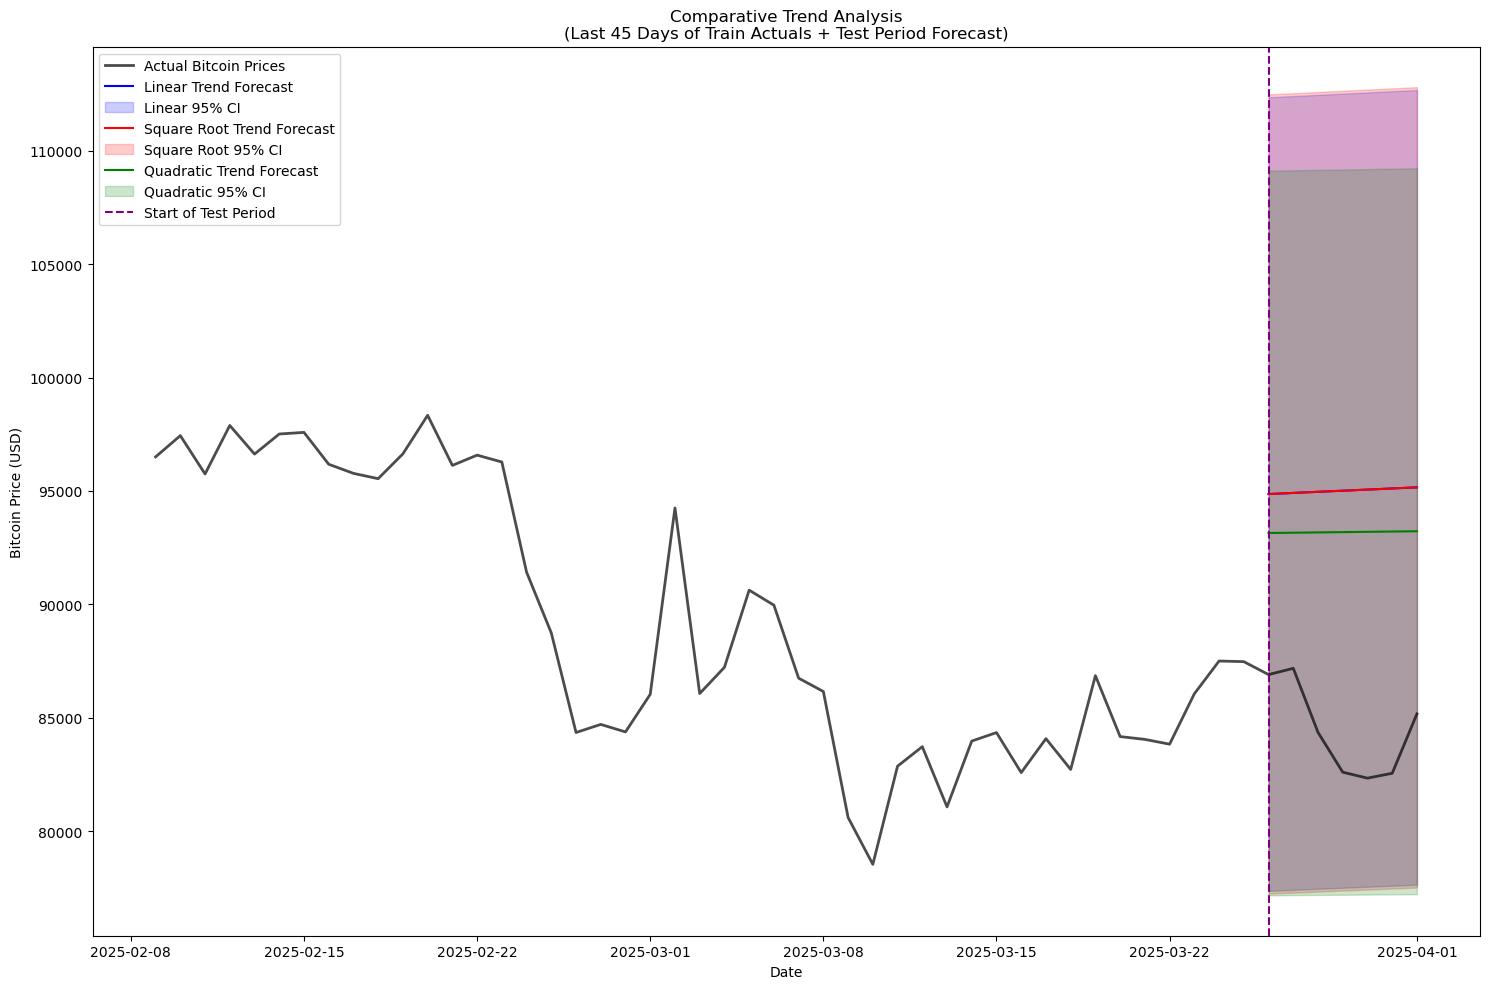

In [ ]:
# Apply the 'calculate_metrics' function for the test data for all three models
model_dicts = []
for model_name, forecast_df in zip(model_names, model_forecasts):
    metrics = calculate_metrics(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])
    model_dict = {"Model": model_name}
    model_dict['MSPE_test'] = metrics['MSPE']
    model_dict['MAE_test'] = metrics['MAE']
    model_dict['MAPE_test'] = metrics['MAPE']
    model_dict['Precision_Error_test'] = metrics['Precision_error']
    model_dicts.append(model_dict)

prediction_metrics = pd.DataFrame(model_dicts)


# Display Prediction Results
print("Comparative Metrics:")
print(prediction_metrics)

# Define test start and plot start
test_start = test['ts'].iloc[0]
days_to_show_from_train = 45
plot_start = test_start - pd.Timedelta(days=days_to_show_from_train)

# Filter data for plotting
plot_df = df[df['ts'] >= plot_start]
linear_forecast_df = linear_result.forecast.df[linear_result.forecast.df['ts'] >= test_start]
sqrt_forecast_df = sqrt_result.forecast.df[sqrt_result.forecast.df['ts'] >= test_start]
quadratic_forecast_df = quadratic_result.forecast.df[quadratic_result.forecast.df['ts'] >= test_start]

# Create the plot
plt.figure(figsize=(15, 10))
# Plot actual prices for both train and test periods
plt.plot(plot_df['ts'], plot_df['y'], label='Actual Bitcoin Prices', color='black', linewidth=2, alpha=0.7)
# Plot forecasts only for test period
plt.plot(linear_forecast_df['ts'], linear_forecast_df['forecast'],
         label='Linear Trend Forecast', color='blue', linewidth=1.5)
plt.fill_between(linear_forecast_df['ts'],
                 linear_forecast_df['forecast_lower'],
                 linear_forecast_df['forecast_upper'],
                 color='blue', alpha=0.2, label='Linear 95% CI')

plt.plot(sqrt_forecast_df['ts'], sqrt_forecast_df['forecast'],
         label='Square Root Trend Forecast', color='red', linewidth=1.5)
plt.fill_between(sqrt_forecast_df['ts'],
                 sqrt_forecast_df['forecast_lower'],
                 sqrt_forecast_df['forecast_upper'],
                 color='red', alpha=0.2, label='Square Root 95% CI')

plt.plot(quadratic_forecast_df['ts'], quadratic_forecast_df['forecast'],
         label='Quadratic Trend Forecast', color='green', linewidth=1.5)
plt.fill_between(quadratic_forecast_df['ts'],
                 quadratic_forecast_df['forecast_lower'],
                 quadratic_forecast_df['forecast_upper'],
                 color='green', alpha=0.2, label='Quadratic 95% CI')

# Add vertical line for test start
plt.axvline(x=test_start, color='purple', linestyle='--', label='Start of Test Period')

# Set labels and title
plt.xlabel('Date')
plt.ylabel('Bitcoin Price (USD)')
plt.title(f'Comparative Trend Analysis\n(Last {days_to_show_from_train} Days of Train Actuals + Test Period Forecast)')
plt.legend()

plt.tight_layout()
plt.show()




**Insights from this analysis**: Based on the comparison above, the precision metric is better for the quadratric trend in the test data. We also note that the confidence band for the quadratic trend is less wide than for other trend models. Also note that the accuracy measures are much poor in performance than for the train data. We see that all predictions are away from the observations because of the estimate of the overall trend.

### Prediction using CV Approach in Greykite

The code below prints the metrics from the train_evaluation and test_evaluation measure. Greykite library computes this measure using the data provided as input and creating various folds of data, as described below, based on the forecast horizon and other parameters as specified.

Greykite library does something known as the *rolling forward validation* for time series. As time series data is ordered, the cross validation technique does not work. Thus, here, we perform rolling forward cross validation meaning that the split of data is done in a rolling fashion. For example, if we want to do 3-fold rolling forward validation and the forecast horizon is 365 days.
The forecast model's performance will be the average of the three evaluations on the forecasts.

In the greykite library, the split performance on train and test can be obtained using the train_evaulation and test_evaluation as shown below -

```
result = forecaster.run_forecast_config(df=train, config=config)
print(result.backtest.train_evaluation)
print(result.backtest.test_evaluation)
```


In [ ]:
# Get training metrics
linear_train_metrics = linear_result.backtest.train_evaluation
sqrt_train_metrics = sqrt_result.backtest.train_evaluation
quadratic_train_metrics = quadratic_result.backtest.train_evaluation

# Get test metrics
linear_test_metrics = linear_result.backtest.test_evaluation
sqrt_test_metrics = sqrt_result.backtest.test_evaluation
quadratic_test_metrics = quadratic_result.backtest.test_evaluation

metrics = ['MAPE','MAE']
# Create DataFrames for train and test metrics
train_metrics_df = pd.DataFrame({
    'Metric': metrics,
    'Linear': [linear_train_metrics[metric] for metric in metrics],
    'Square Root': [sqrt_train_metrics[metric] for metric in metrics],
    'Quadratic': [quadratic_train_metrics[metric] for metric in metrics]
})

test_metrics_df = pd.DataFrame({
    'Metric': metrics,
    'Linear': [linear_test_metrics[metric] for metric in metrics],
    'Square Root': [sqrt_test_metrics[metric] for metric in metrics],
    'Quadratic': [quadratic_test_metrics[metric] for metric in metrics]
})

# Print metrics tables
print("=== TRAINING SET METRICS ===")
print(train_metrics_df.to_string(index=False))
print("\n=== TEST SET METRICS ===")
print(test_metrics_df.to_string(index=False))

=== TRAINING SET METRICS ===
Metric      Linear  Square Root   Quadratic
  MAPE   28.031581    28.932092   24.300614
   MAE 6775.331966  6844.499351 6152.589512

=== TEST SET METRICS ===
Metric       Linear  Square Root    Quadratic
  MAPE    19.255443    19.252499    19.373607
   MAE 16472.714480 16470.190512 16573.915086


**Insights from this analysis**: The metrics provided above provide different results than the prediction accuracy measures in the evaluation for our test data because of the approach used because of the way it computes the accuracy measures. Also note the Greykite does not have implemented the precision measure. For the ease of comparison across all forecasting system, we will use the first approach to evaluate prediction accuracy.

#Changepoint Grid Search

Changepoints are points in time where the trend (or seasonality) of the time series changes abruptly. For trends, this might mean a change in slope or level (e.g., from flat to steeply increasing). For seasonality, it could mean a shift in the seasonal pattern's amplitude or shape. They make the model more adaptive by allowing the growth term (e.g., linear, quadratic) to vary across different segments of the time series, capturing structural breaks or regime changes.


Silverkite uses a statistical approach to detect potential changepoints, fitting a piecewise model where the trend (or seasonality) parameters differ before and after each changepoint. Changepoints can be of various types like *Trend Changepoints* that adjust the growth term (e.g., changing the slope of a linear trend) and *Seasonality Changepoints* that modify seasonal patterns (e.g., weekly seasonality becoming stronger after an event).

 **Experiment Details-**

 Here, we are trying to tune changepoint hyperparameters by fixing the growth term, for example as quadratic trend, and keeping other components as 'off' or None. In this analysis, we are performing grid search on hyperparameters such as regularization_strength, no_changepoint_proportion_from_end, potential_changepoint_n, and resample_freq.These hyperparameters are described below:
 1. *method*: Specifies the method for detecting changepoints. The "auto" setting means Silverkite automatically places potential changepoints across the time series and selects the most significant ones based on the data. It can also be "uniform" which places changepoints at fixed intervals and "custom" where User specifies exact changepoint dates. For our experiment, the method used is "auto".
 2. *regularization_strength*: Controls the penalty applied to the number and magnitude of changepoints, preventing overfitting by discouraging unnecessary changepoints. The value of this hyperparameter is between 0 and 1.
 3. *no_changepoint_proportion_from_end*: Specifies the proportion of the time series at the end where no changepoints are allowed. This ensures the model doesn't place changepoints too close to the forecast period, improving stability.
 4. *potential_changepoint_n*: The maximum number of potential changepoints the model considers before selecting the most significant ones (via regularization).
 5. *resample_freq*: The frequency at which potential changepoints are placed in the time series. It defines the granularity of candidate changepoint locations.For example, 7D' means that the model places potential changepoints at weekly intervals.

In [ ]:
param_grid = {
    'regularization_strength': [ 0.1, 0.5],  # Low to moderate regularization
    'no_changepoint_proportion_from_end': [0, 0.1, 0.2],  # 0% to 20% of data at end with no changepoints
    'potential_changepoint_n': [10, 20],  # Number of changepoints
    'resample_freq': ['1D', '7D']
}

# --- Generate all combinations ---
param_combinations = list(itertools.product(
    param_grid['regularization_strength'],
    param_grid['no_changepoint_proportion_from_end'],
    param_grid['potential_changepoint_n'],
    param_grid['resample_freq']
))

# --- Store Results ---
results = []

# --- Hyperparameter Tuning Loop ---
forecaster = Forecaster()
for reg_strength, no_cp_prop, n_cp, res_freq in param_combinations:
    print(f"Testing: reg_strength={reg_strength}, no_cp_prop={no_cp_prop}, n_cp={n_cp}, res_freq={res_freq}")

    # Define the forecast config with quadratic trend and tuned changepoints
    config = ForecastConfig(
        model_template="SILVERKITE",
        forecast_horizon=7,
        coverage=0.95,
        metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
        model_components_param=ModelComponentsParam(
            growth={"growth_term": "quadratic"},
            changepoints={
                "changepoints_dict": {
                    "method": "auto",
                    "regularization_strength": reg_strength,
                    "no_changepoint_proportion_from_end": no_cp_prop,
                    "potential_changepoint_n": n_cp,
                    "resample_freq": res_freq
                }
            },
            seasonality={"yearly_seasonality": False, "quarterly_seasonality": False,
                         "monthly_seasonality": False, "weekly_seasonality": False,
                         "daily_seasonality": False, "auto_seasonality": False},
            events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
            autoregression={"autoreg_dict": None},
            regressors={"regressor_cols": []},
            uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
            custom={
                "feature_sets_enabled": False,
                "extra_pred_cols": [],
                "fit_algorithm_dict": {"fit_algorithm": "ridge"}
            }
        )
    )

    # Run the forecast
    result = forecaster.run_forecast_config(df=train, config=config)
    forecast_df = result.forecast.df

    # Merge with actual data
    forecast_df = forecast_df.merge(df[['ts', 'y']], on='ts', how='left')

    # Split into train and test periods
    test_start = test['ts'].iloc[0]
    test_period = forecast_df['ts'] >= test_start

    # Calculate prediction accuracy metrics on test dataset for comparison across all combinations
    mape_test = mean_absolute_percentage_error(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])
    precision_test = calculate_precision_error(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])

    # Store results
    results.append({
        'reg_strength': reg_strength,
        'no_cp_prop': no_cp_prop,
        'potential_changepoint_n': n_cp,
        'resample_freq': res_freq,
        'MAPE_Test': mape_test,
        'Precision_Test':precision_test,
        'changepoints': result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])
    })

# --- Convert Results to DataFrame ---
results_df = pd.DataFrame(results)

Testing: reg_strength=0.1, no_cp_prop=0, n_cp=10, res_freq=1D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0, n_cp=10, res_freq=7D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0, n_cp=20, res_freq=1D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0, n_cp=20, res_freq=7D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0.1, n_cp=10, res_freq=1D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0.1, n_cp=10, res_freq=7D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0.1, n_cp=20, res_freq=1D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.1, no_cp_prop=0.1, n_cp=20, res_freq=7D
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Testing: reg_strength=0.

In [ ]:
# --- Sort by Precision Measure to find the best model ---
results_df = results_df.sort_values('Precision_Test').reset_index(drop=True)
print("\nHyperparameter Tuning Results (sorted by Precision_Test):")
print(results_df[['reg_strength', 'no_cp_prop', 'potential_changepoint_n', 'resample_freq', 'Precision_Test']])

# --- Best Configuration ---
best_config = results_df.iloc[0]
print("\nBest Configuration:")
print(f"Regularization Strength: {best_config['reg_strength']}")
print(f"No Changepoint Proportion from End: {best_config['no_cp_prop']}")
print(f"Number of Changepoints: {best_config['potential_changepoint_n']}")
print(f"Resample Frequency: {best_config['resample_freq']}")
print(f"MAPE on Test: {best_config['MAPE_Test']:.2f}%")
print(f"Precision Measure on Test: {best_config['Precision_Test']:.2f}")
print(f"Changepoints: {best_config['changepoints']}")


Hyperparameter Tuning Results (sorted by Precision_Test):
    reg_strength  no_cp_prop  potential_changepoint_n resample_freq  \
0            0.5         0.0                       20            1D   
1            0.5         0.0                       20            7D   
2            0.1         0.0                       20            7D   
3            0.1         0.0                       20            1D   
4            0.1         0.2                       10            1D   
5            0.1         0.2                       10            7D   
6            0.1         0.1                       10            7D   
7            0.5         0.1                       10            1D   
8            0.5         0.0                       10            1D   
9            0.5         0.2                       10            1D   
10           0.1         0.1                       20            7D   
11           0.5         0.0                       10            7D   
12           0.5  

**Insights from this analysis**: The best hyperparameter combination comes out to be regularization_strength = 0.5, no_changepoint_proportion_from_end = 0.0,  potential_changepoint_n=20, and resample_freq=1D. The computation of the accuracy metrics for this hyperparmeter set and the plots on the train and test set can be found below.

Fitting 3 folds for each of 1 candidates, totalling 3 fits


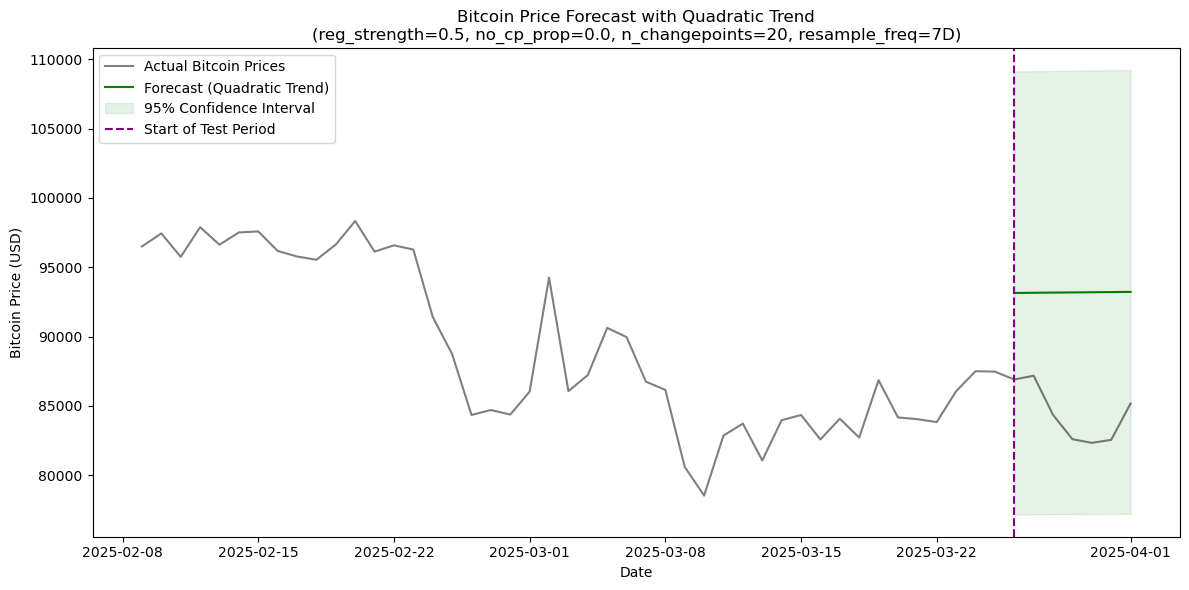

Comparative Metrics:
{'MSPE': 80131857.34836815, 'MAE': 8742.371763614245, 'MAPE': 10.409799724992709, 'Precision_error': 22.00506547893753}


In [ ]:
config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": "quadratic"},
        changepoints={
            "changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"
            }
        },
        seasonality={"yearly_seasonality": False, "quarterly_seasonality": False,
                     "monthly_seasonality": False, "weekly_seasonality": False,
                     "daily_seasonality": False, "auto_seasonality": False},
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

# Run Forecast
forecaster = Forecaster()
result = forecaster.run_forecast_config(df=train, config=config)
forecast_df = result.forecast.df
changepoints = result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])

# Merge Forecast with Actual Data
forecast_df = forecast_df.merge(df[['ts', 'y']], on='ts', how='left')

# Define Plotting Window
test_start = test['ts'].iloc[0]
days_to_show_from_train = 45
plot_start = test_start - pd.Timedelta(days=days_to_show_from_train)

# Filter data for plotting
plot_df = df[df['ts'] >= plot_start]
plot_forecast_df = forecast_df[forecast_df['ts'] >= test_start]

# Plotting
plt.figure(figsize=(12, 6))

# Actual Bitcoin Prices
plt.plot(plot_df['ts'], plot_df['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Forecast (only for test period)
plt.plot(plot_forecast_df['ts'], plot_forecast_df['forecast'], label='Forecast (Quadratic Trend)', color='green')
plt.fill_between(plot_forecast_df['ts'], plot_forecast_df['forecast_lower'], plot_forecast_df['forecast_upper'],
                 color='green', alpha=0.1, label='95% Confidence Interval')

# Test Period Start
plt.axvline(x=test_start, color='purple', linestyle='--', label='Start of Test Period')

# Changepoints
for cp in changepoints:
    if cp >= plot_start:  # Only plot changepoints within the window
        plt.axvline(x=cp, color='blue', linestyle=':', alpha=0.7,
                    label='Changepoints' if cp == changepoints[0] else "")

# Customize Plot
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Bitcoin Price Forecast with Quadratic Trend\n(reg_strength=0.5, no_cp_prop=0.0, n_changepoints=20, resample_freq=7D)")
plt.legend()
plt.tight_layout()

# Show Plot
plt.show()

# Calculate Metrics on Test Set
test_period = forecast_df['ts'] >= test_start
train_period = forecast_df['ts'] < test_start


prediction_metrics = calculate_metrics(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])
print("Comparative Metrics:")
print(prediction_metrics)


**Insights from this analysis**: The mape on  the test set is 10.41%. The precision measure is 22 on the test data, relatively large value. As we compare with the accuracy measures when fitting the trend only, we find that this grid search  provides a much better prediction than when using a model with no change points.

In the next plot, we evaluate the selection of change points.

Fitting 3 folds for each of 1 candidates, totalling 3 fits


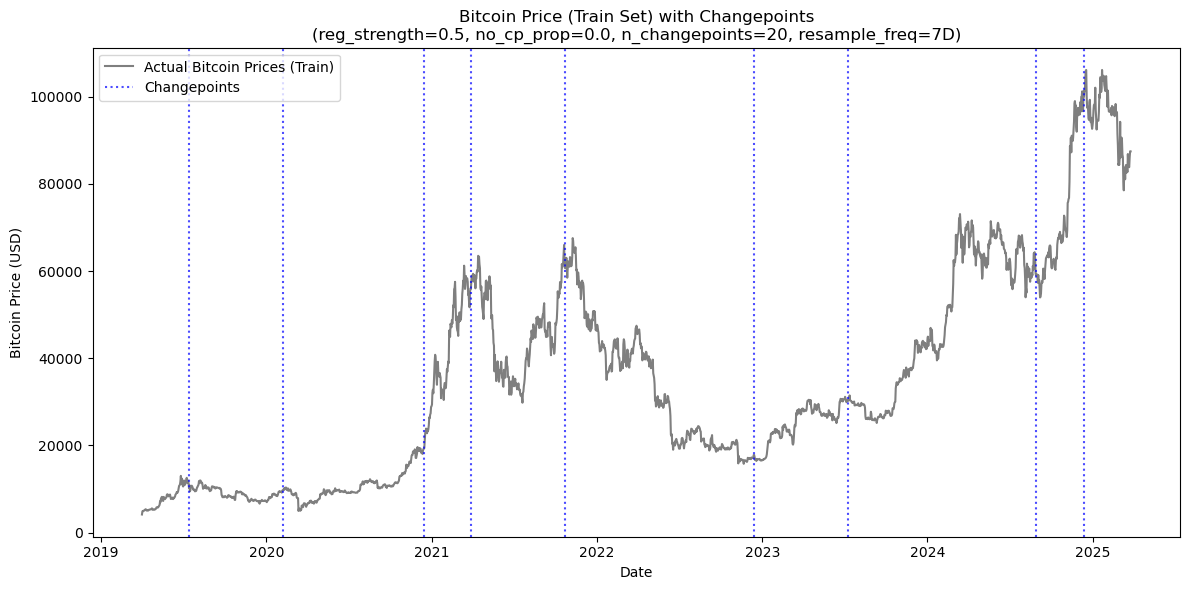

Detected Changepoints: [Timestamp('2019-07-14 00:00:00'), Timestamp('2020-02-07 00:00:00'), Timestamp('2020-12-15 00:00:00'), Timestamp('2021-03-29 00:00:00'), Timestamp('2021-10-23 00:00:00'), Timestamp('2022-12-14 00:00:00'), Timestamp('2023-07-10 00:00:00'), Timestamp('2024-08-29 00:00:00'), Timestamp('2024-12-11 00:00:00')]


In [ ]:
forecaster = Forecaster()
result = forecaster.run_forecast_config(df=train, config=config)
changepoints = result.forecast.estimator.model_dict.get('trend_changepoint_dates', [])

# --- Plotting on Train Set ---
plt.figure(figsize=(12, 6))

# Plot actual Bitcoin prices for the train set
plt.plot(train['ts'], train['y'], label='Actual Bitcoin Prices (Train)', color='black', alpha=0.5)

# Plot changepoints as vertical lines
for i, cp in enumerate(changepoints):
    plt.axvline(x=cp, color='blue', linestyle=':', alpha=0.7,
                label='Changepoints' if i == 0 else None)

# Customize Plot
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Bitcoin Price (Train Set) with Changepoints\n(reg_strength=0.5, no_cp_prop=0.0, n_changepoints=20, resample_freq=7D)")
plt.legend()
plt.tight_layout()

# Show Plot
plt.show()

# --- Print Changepoints ---
print(f"Detected Changepoints: {changepoints}")

**Insights from this analysis**: The selection of the change points captures some of the variations in the time series. However, not all the variations are captured as resample frequency is taken as 1 day and the regularization strength is 0.5, a moderate value for this hyperparameter that limits the number of changepoints.

# Analysis of the Seasonality Component

Silverkite uses Fourier series to model seasonality. Higher Fourier orders allow more complex patterns but risk overfitting. Each seasonality type (e.g., yearly, weekly) is modeled independently and combined additively with other components (trend, holidays, etc.).
For seasonality, we are considering following hyperparameters (These are all boolean parameters) -
* **yearly_seasonality:** Models patterns that repeat annually, typically with a period of 365.25 days (accounting for leap years).
* **quarterly_seasonality:** Models patterns that repeat every quarter (three months), with a period of ~91.3125 days (365.25/4).
* **monthly_seasonality:** Models patterns that repeat every month, with a period of ~30.42 days (365.25/12).
* **weekly_seasonality:** Models patterns that repeat every week, with a period of 7 days.
* **daily_seasonality:** Models patterns that repeat every day, with a period of 1 day (used for sub-daily data, e.g., hourly).


In addition to setting up the period, Silverkite is also using other seasonality hyperparameters. This is specified under 'changepoint dict'.

Some of the hyperparameters are -
* **period** - The period of the seasonal component, expressed in the time unit of the data (typically days for daily data). It defines the length of one complete seasonal cycle.
* **order** - The Fourier order for the seasonal component, which determines the complexity of the seasonal pattern. It specifies the number of sine and cosine terms used in the Fourier series to model the seasonality.
* **name** - The internal name of the seasonal component, used in the model’s feature generation.
* **seas_names** - The user-friendly name for the seasonal component

More details can be found here - https://linkedin.github.io/greykite/docs/0.1.0/html/pages/model_components/0500_changepoints.html

*Note*: If we specify the 'order' in the seasonality_changepoint_dict then that order is also used as the seasonality order. If the other components are also active then the default value is used for them if not used anywhere.

In this first analysis below, we are keeping yearly_seasonality as True and rest of the seasonality types as False, meaning that we only include yearly seasonality. We also consider two models,  without seasonality changepoints versus with seasonality changepoints.

##### Seasonality with Change Points

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


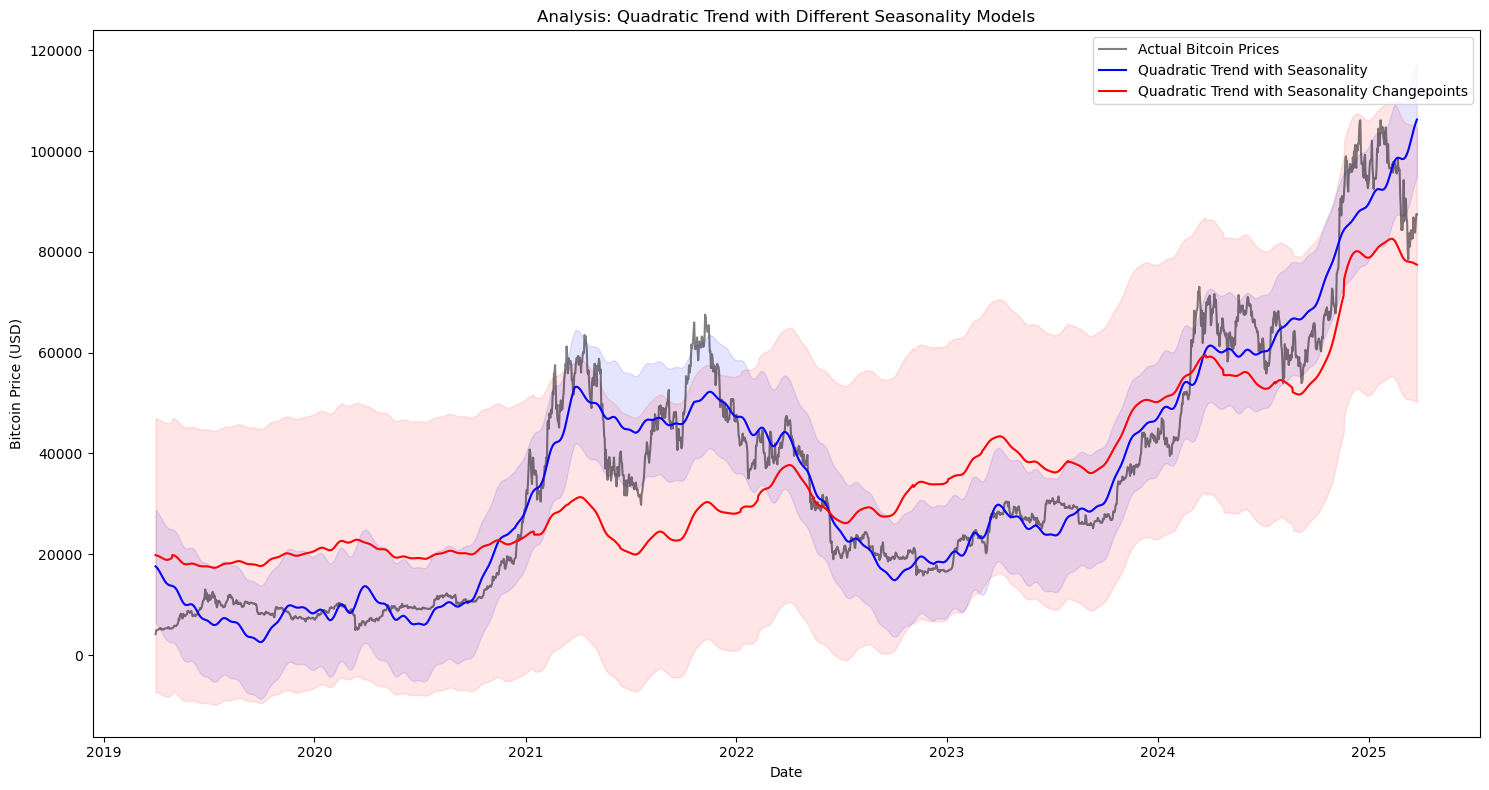

In [ ]:
selected_trend = "quadratic"

# --- Model with Yearly Seasonality but Without Seasonality Changepoints ---
seasonality_no_cp_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"
            }
                      },
        #Seasonality Type (only yearly considered here)
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

forecaster = Forecaster()
seasonality_no_cp_result = forecaster.run_forecast_config(df=train, config=seasonality_no_cp_config)
seasonality_no_cp_forecast_df = seasonality_no_cp_result.forecast.df
seasonality_no_cp_backtest_df = seasonality_no_cp_result.backtest.df

# Model with Yearly Seasonality & Seasonality Changepoints
seasonality_with_cp_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={
            "changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"
            },
            "seasonality_changepoints_dict": dict(
        potential_changepoint_distance="30D",
        seasonality_components_df=pd.DataFrame({
        "name": ["tow", "conti_year"],
        "period": [7.0, 1.0],
        "order": [4, 6],
        "seas_names": ["weekly", "yearly"]})
    )
        },
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

seasonality_with_cp_result = forecaster.run_forecast_config(df=train, config=seasonality_with_cp_config)
seasonality_with_cp_forecast_df = seasonality_with_cp_result.forecast.df
seasonality_with_cp_backtest_df = seasonality_with_cp_result.backtest.df

# Plot Results
plt.figure(figsize=(15, 8))

# Plot actual prices from train and test
plt.plot(train['ts'], train['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# # Identify test period in backtest data (where forecast is not NaN)
test_period = seasonality_no_cp_backtest_df['forecast'].notna()

# Plot backtest forecast for model without seasonality changepoints (test period)
plt.plot(seasonality_no_cp_backtest_df['ts'][test_period], seasonality_no_cp_backtest_df['forecast'][test_period],
         label=f'{selected_trend.capitalize()} Trend with Seasonality', color='blue')
plt.fill_between(seasonality_no_cp_backtest_df['ts'][test_period],
                 seasonality_no_cp_backtest_df['forecast_lower'][test_period],
                 seasonality_no_cp_backtest_df['forecast_upper'][test_period],
                 color='blue', alpha=0.1)

# Plot backtest forecast for model with seasonality changepoints (test period)
plt.plot(seasonality_with_cp_backtest_df['ts'][test_period], seasonality_with_cp_backtest_df['forecast'][test_period],
         label=f'{selected_trend.capitalize()} Trend with Seasonality Changepoints', color='red')
plt.fill_between(seasonality_with_cp_backtest_df['ts'][test_period],
                 seasonality_with_cp_backtest_df['forecast_lower'][test_period],
                 seasonality_with_cp_backtest_df['forecast_upper'][test_period],
                 color='red', alpha=0.1)

# Add vertical line at the start of the test period
test_start = test['ts'].iloc[0]
# plt.axvline(x=test_start, color='purple', linestyle='--', label='Start of Test Period')

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.legend()
plt.title(f"Analysis: {selected_trend.capitalize()} Trend with Different Seasonality Models")
plt.tight_layout()
plt.show()

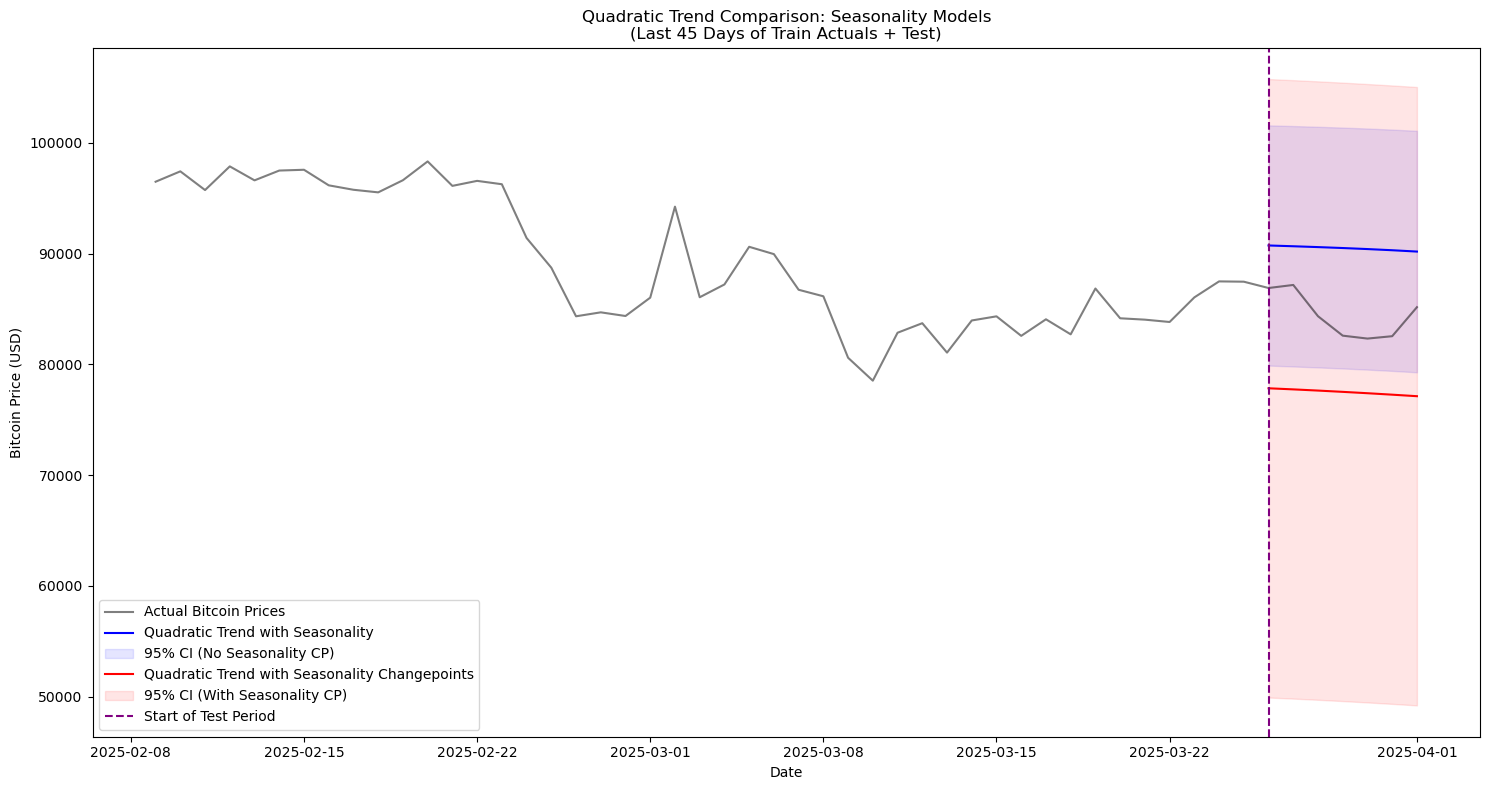

In [ ]:
# Define test start and plotting window
test_start = test['ts'].iloc[0]
days_to_show_from_train = 45
plot_start = test_start - pd.Timedelta(days=days_to_show_from_train)

# Filter dataframes for the plotting window
plot_df = df[df['ts'] >= plot_start]
seasonality_no_cp_forecast_df = seasonality_no_cp_result.forecast.df[seasonality_no_cp_result.forecast.df['ts'] >= test_start]
seasonality_with_cp_forecast_df = seasonality_with_cp_result.forecast.df[seasonality_with_cp_result.forecast.df['ts'] >= test_start]

# Plotting
plt.figure(figsize=(15, 8))

# Plot actual prices for both train and test periods
plt.plot(plot_df['ts'], plot_df['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Plot forecast for model without seasonality changepoints (test period only)
plt.plot(seasonality_no_cp_forecast_df['ts'], seasonality_no_cp_forecast_df['forecast'],
         label=f'{selected_trend.capitalize()} Trend with Seasonality', color='blue', linewidth=1.5)
plt.fill_between(seasonality_no_cp_forecast_df['ts'],
                 seasonality_no_cp_forecast_df['forecast_lower'],
                 seasonality_no_cp_forecast_df['forecast_upper'],
                 color='blue', alpha=0.1, label='95% CI (No Seasonality CP)')

# Plot forecast for model with seasonality changepoints (test period only)
plt.plot(seasonality_with_cp_forecast_df['ts'], seasonality_with_cp_forecast_df['forecast'],
         label=f'{selected_trend.capitalize()} Trend with Seasonality Changepoints', color='red', linewidth=1.5)
plt.fill_between(seasonality_with_cp_forecast_df['ts'],
                 seasonality_with_cp_forecast_df['forecast_lower'],
                 seasonality_with_cp_forecast_df['forecast_upper'],
                 color='red', alpha=0.1, label='95% CI (With Seasonality CP)')

# Add vertical line at the start of the test period
plt.axvline(x=test_start, color='purple', linestyle='--', label='Start of Test Period')

# Customize plot
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title(f"{selected_trend.capitalize()} Trend Comparison: Seasonality Models\n(Last {days_to_show_from_train} Days of Train Actuals + Test)")
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

In [ ]:


no_cp_forecast_full = pd.merge(df, seasonality_no_cp_result.forecast.df, on='ts', how='left')
with_cp_forecast_full = pd.merge(df, seasonality_with_cp_result.forecast.df, on='ts', how='left')
test_start = test['ts'].iloc[0]
test_period = no_cp_forecast_full['ts'] >= test_start

# Calculate Fit Accuracy Measures for Each Model using the Test Data
model_names = ['Seasonality No Change Points', 'Seasonality + Change Points']
model_forecasts = [no_cp_forecast_full, with_cp_forecast_full]

# for model_name, forecast_df in zip(model_names, model_forecasts):
#     metrics = calculate_metrics(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])
#     model_dict = {"Model":model_name}
#     model_dict['MAPE_test'] = metrics['MAPE']
#     model_dict['MAE_test'] = metrics['MAE']
#     model_dict['Precision_Error_test'] = metrics['Precision_eror']
#     model_dicts.append(model_dict)
# prediction_metrics = pd.DataFrame(model_dicts)

model_dicts = []
for model_name, forecast_df in zip(model_names, model_forecasts):
    metrics = calculate_metrics(forecast_df.loc[test_period, 'y'], forecast_df.loc[test_period, 'forecast'])
    model_dict = {"Model": model_name}
    model_dict['MSPE_test'] = metrics['MSPE']
    model_dict['MAE_test'] = metrics['MAE']
    model_dict['MAPE_test'] = metrics['MAPE']
    model_dict['Precision_Error_test'] = metrics['Precision_error']
    model_dicts.append(model_dict)

prediction_metrics = pd.DataFrame(model_dicts)


# Display Prediction Results
print("Comparative Metrics:")
print(prediction_metrics)



Comparative Metrics:
                          Model     MSPE_test     MAE_test  MAPE_test  \
0  Seasonality No Change Points  3.992042e+07  6052.177632   7.219197   
1   Seasonality + Change Points  5.123864e+07  6933.157514   8.167765   

   Precision_Error_test  
0             10.962576  
1             14.070679  


Based on the training and testing MAPE, the seasonality changepoint does not have any effect on the model as the accuracy measures are all higher for the model with seasonality change points versus the model without.

##### Evaluating Different Seasonality Periods

So far we only considered a simple implementation of the seasonality, considering all seasonality parameters to be 'off'. Next, we will compare seasonality fit considering all seasonality parameters as ON and considering one seasonality parameters as ON at a time. In this experiment, we are comparing yearly only seasonality, quarterly only seasonality, monthly only seasonality, weekly only seasonality and comparing it with the model where we are keeping all these hyperparameters as ON.

In the analysis below, we will compare how different types of seasonality performs. Recall that we only considered yearly seasonality in the inital implementation of the seasonality component. Now we will consider weekly, monthly, quartely and yearly, separately and in combination. Note that we will keep the same configuration of the change points for seasonality across all such comparisons.

Running model with Weekly Only seasonality...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Running model with Monthly Only seasonality...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Running model with Quarterly Only seasonality...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Running model with Yearly Only seasonality...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Running model with all seasonality components...
Fitting 3 folds for each of 1 candidates, totalling 3 fits


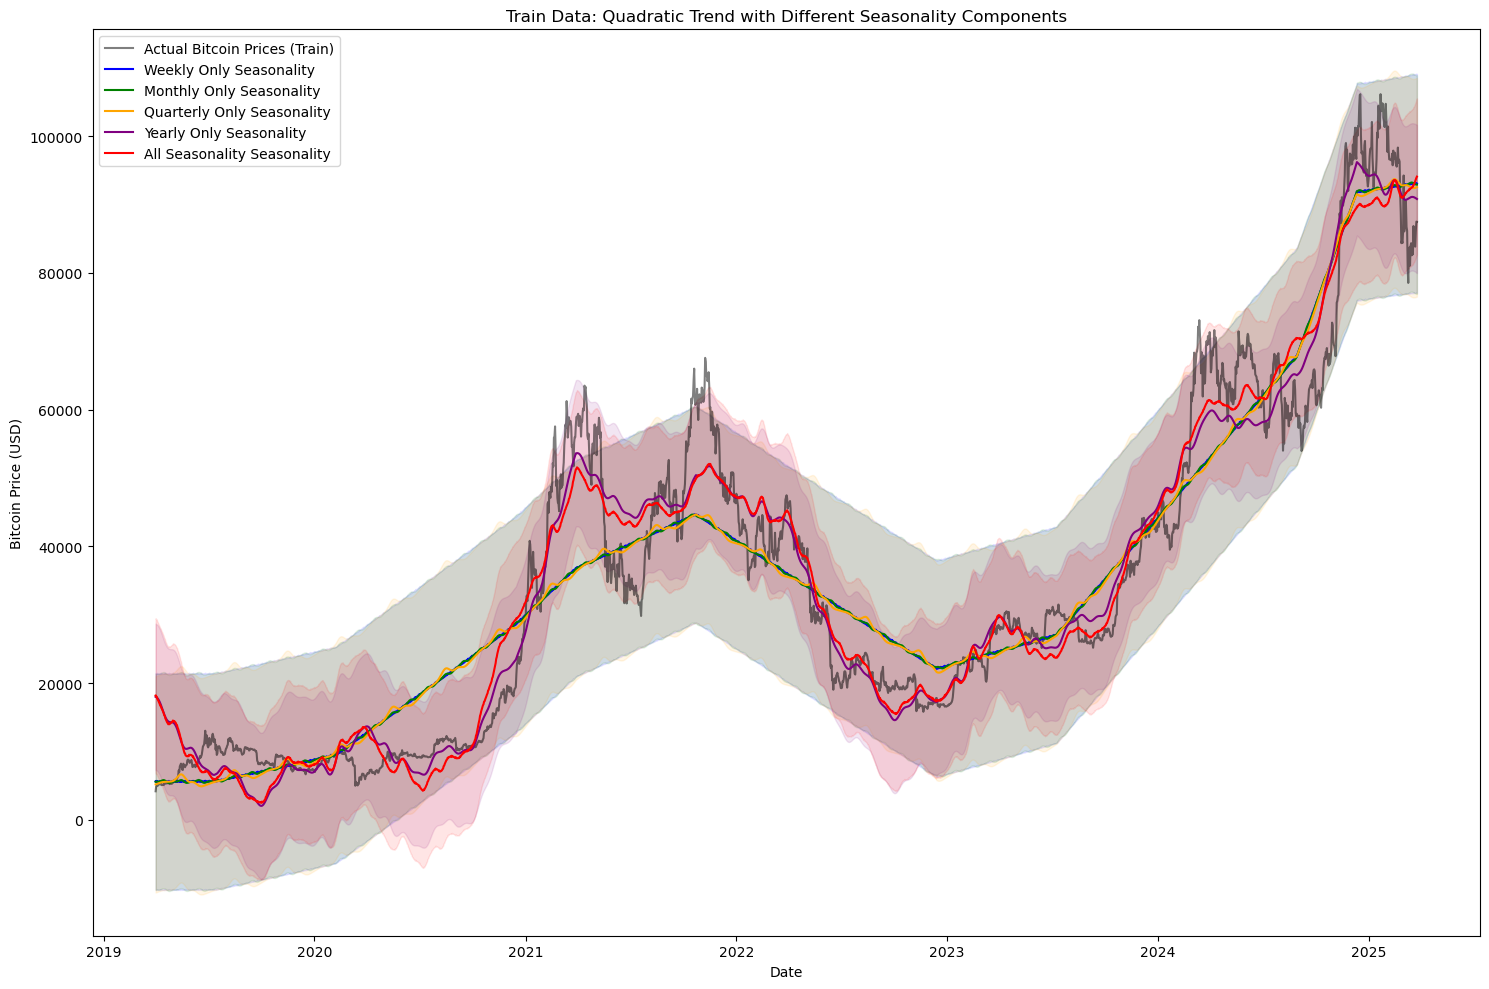


Model Performance Comparison (Train):
                         MSPE          MAE       MAPE  Precision_error
Weekly Only      6.446808e+07  6273.143161  26.370957         0.107754
Monthly Only     6.445335e+07  6269.606187  26.357297         0.107729
Quarterly Only   6.424515e+07  6253.993789  26.131508         0.107381
Yearly Only      2.864745e+07  4096.347607  18.582016         0.047882
All Seasonality  3.146521e+07  4367.797169  20.094082         0.052592

Model Performance Comparison (Test):
                         MSPE           MAE       MAPE  Precision_error
Weekly Only      8.013211e+07   8743.851397  10.411370        22.005134
Monthly Only     7.818087e+07   8620.843224  10.266857        21.469304
Quarterly Only   7.245084e+07   8281.945592   9.865292        19.895776
Yearly Only      3.992042e+07   6052.177632   7.219197        10.962576
All Seasonality  1.133274e+08  10434.508430  12.419616        31.120907


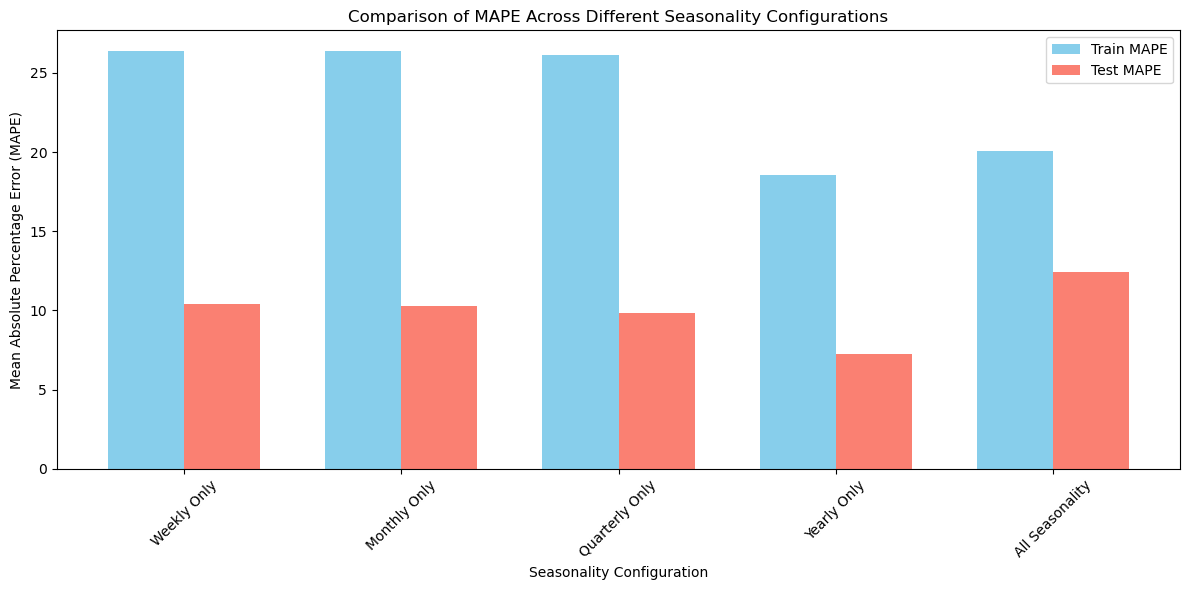

In [ ]:
selected_trend = "quadratic"

# List of seasonality configurations to test
seasonality_configs = [
    {"name": "Weekly Only", "weekly": True, "monthly": False, "quarterly": False, "yearly": False},
    {"name": "Monthly Only", "weekly": False, "monthly": True, "quarterly": False, "yearly": False},
    {"name": "Quarterly Only", "weekly": False, "monthly": False, "quarterly": True, "yearly": False},
    {"name": "Yearly Only", "weekly": False, "monthly": False, "quarterly": False, "yearly": True},
]

# Store results for each configuration
results = []
forecast_dfs = []

# Run forecasts for each seasonality configuration
for config in seasonality_configs:
    print(f"Running model with {config['name']} seasonality...")

    model_config = ForecastConfig(
        model_template="SILVERKITE",
        forecast_horizon=7,
        coverage=0.95,
        metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
        model_components_param=ModelComponentsParam(
            growth={"growth_term": selected_trend},
            changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"
            }
                      },
          seasonality={
                "yearly_seasonality": config["yearly"],
                "quarterly_seasonality": config["quarterly"],
                "monthly_seasonality": config["monthly"],
                "weekly_seasonality": config["weekly"],
                "daily_seasonality": False,
            },
            events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
            autoregression={"autoreg_dict": None},
            regressors={"regressor_cols": []},
            uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
            custom={
                "feature_sets_enabled": False,
                "extra_pred_cols": [],
                "fit_algorithm_dict": {"fit_algorithm": "ridge"}
            }
        )
    )

    forecaster = Forecaster()
    result = forecaster.run_forecast_config(df=train, config=model_config)  # Changed df to train
    results.append(result)
    forecast_dfs.append(result.forecast.df)

# Add a model with all seasonality components
print("Running model with all seasonality components...")
all_seasonality_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "7D"
            },
           },
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": True,
            "monthly_seasonality": True,
            "weekly_seasonality": True,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": False,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

forecaster = Forecaster()
all_seasonality_result = forecaster.run_forecast_config(df=train, config=all_seasonality_config)  # Changed df to train
results.append(all_seasonality_result)
forecast_dfs.append(all_seasonality_result.forecast.df)
seasonality_configs.append({"name": "All Seasonality", "weekly": True, "monthly": True, "quarterly": True, "yearly": True})

# Merge forecasts with train and test data
train_forecasts = []
test_forecasts = []
for forecast_df in forecast_dfs:
    train_forecast = train.merge(forecast_df[['ts', 'forecast', 'forecast_lower', 'forecast_upper']],
                                on='ts', how='left')
    test_forecast = test.merge(forecast_df[['ts', 'forecast', 'forecast_lower', 'forecast_upper']],
                              on='ts', how='left')
    train_forecasts.append(train_forecast)
    test_forecasts.append(test_forecast)

# Plot Results - Train
colors = ['blue', 'green', 'orange', 'purple', 'red']
plt.figure(figsize=(15, 10))
plt.plot(train['ts'], train['y'], label='Actual Bitcoin Prices (Train)', color='black', alpha=0.5)

for i, (config, train_forecast) in enumerate(zip(seasonality_configs, train_forecasts)):
    plt.plot(train_forecast['ts'], train_forecast['forecast'],
             label=f'{config["name"]} Seasonality', color=colors[i])
    plt.fill_between(train_forecast['ts'],
                     train_forecast['forecast_lower'],
                     train_forecast['forecast_upper'],
                     color=colors[i], alpha=0.1)

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title(f"Train Data: {selected_trend.capitalize()} Trend with Different Seasonality Components")
plt.legend()
plt.tight_layout()
plt.show()

# Calculate MAPE and MAE for train and test forecasts
metrics_data = {'Train': {}, 'Test': {}}
for i, config in enumerate(seasonality_configs):
    # Train metrics
    train_metrics = calculate_metrics(
        train_forecasts[i]['y'].dropna(),
        train_forecasts[i]['forecast'].dropna()
    )
    metrics_data['Train'][config['name']] = train_metrics

    # Test metrics
    test_metrics = calculate_metrics(
        test_forecasts[i]['y'].dropna(),
        test_forecasts[i]['forecast'].dropna()
    )
    metrics_data['Test'][config['name']] = test_metrics

# Create metrics comparison DataFrames
train_metrics_df = pd.DataFrame.from_dict(metrics_data['Train'], orient='index')
test_metrics_df = pd.DataFrame.from_dict(metrics_data['Test'], orient='index')

print("\nModel Performance Comparison (Train):")
print(train_metrics_df)
print("\nModel Performance Comparison (Test):")
print(test_metrics_df)

# Create bar chart comparing MAPE
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(seasonality_configs))

plt.bar([i - bar_width/2 for i in index],
        [metrics_data['Train'][config['name']]['MAPE'] for config in seasonality_configs],
        bar_width, label='Train MAPE', color='skyblue')

plt.bar([i + bar_width/2 for i in index],
        [metrics_data['Test'][config['name']]['MAPE'] for config in seasonality_configs],
        bar_width, label='Test MAPE', color='salmon')

plt.xlabel('Seasonality Configuration')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.title('Comparison of MAPE Across Different Seasonality Configurations')
plt.xticks(index, [config['name'] for config in seasonality_configs], rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

**Analysis Insights:** Based on the precision metric, the model with yearly only seasonality seems to perform better than all other models. While the model includng all seasonalities also perform well (as can be seen using the MAPE and precision metric), this primarily because it includes the yearly seasonality.

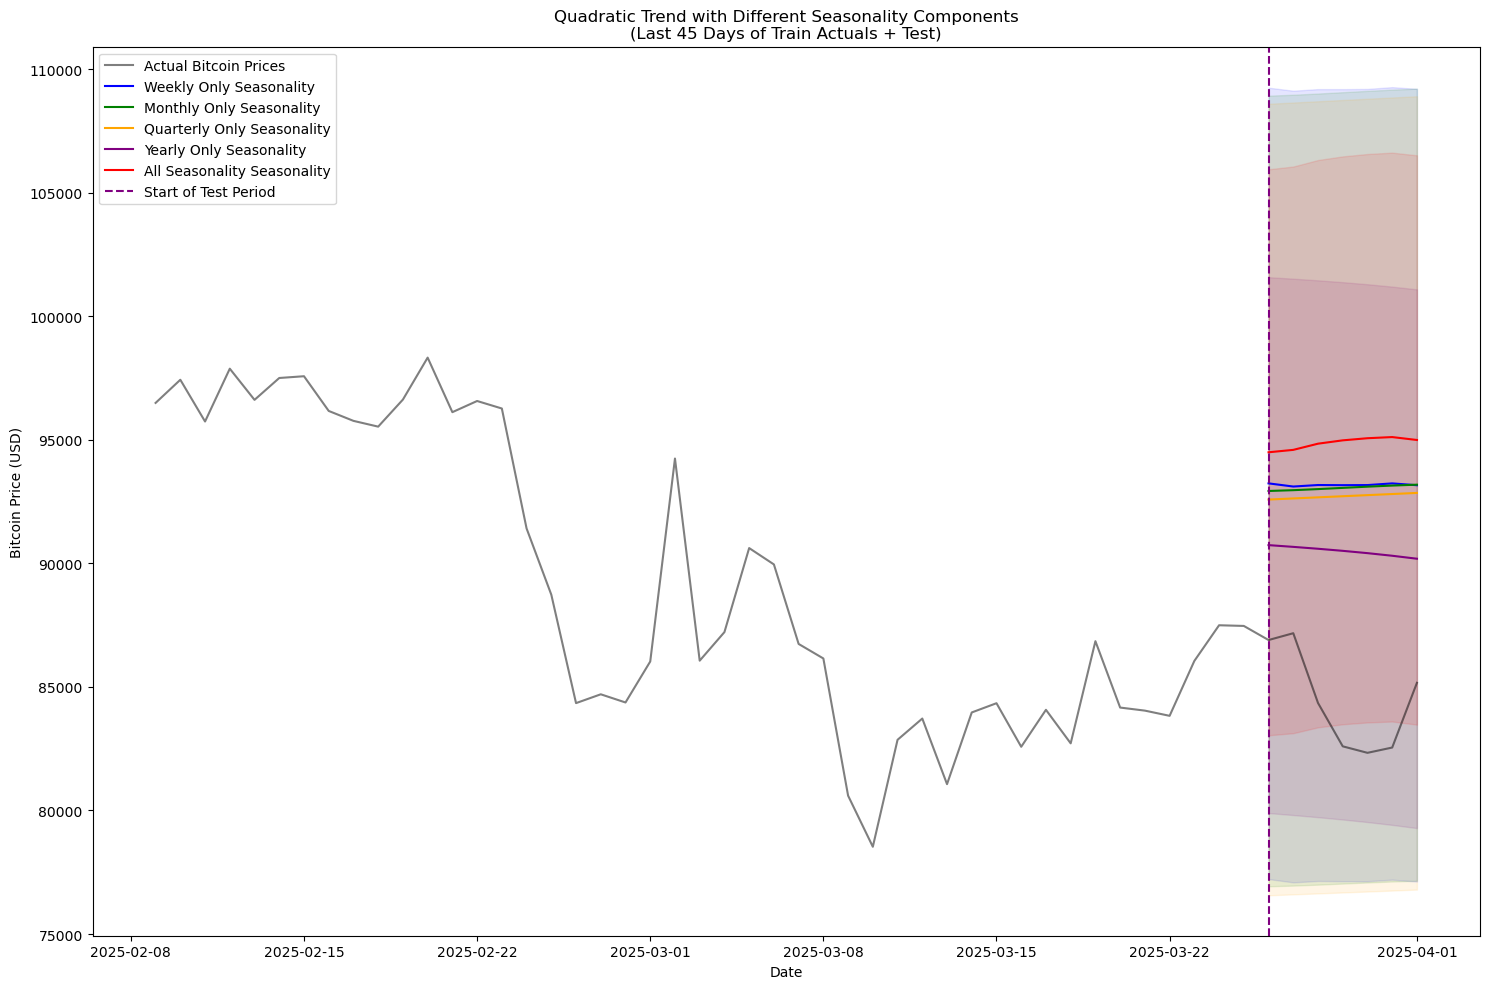

In [ ]:
# Define test start and plotting window
test_start = test['ts'].iloc[0]
days_to_show_from_train = 45
plot_start = test_start - pd.Timedelta(days=days_to_show_from_train)

# Filter train data for the last 35 days
train_plot = train[train['ts'] >= plot_start]

# Combine train and test data for plotting actuals
plot_data = pd.concat([train_plot, test], ignore_index=True)

# Plotting - Train and Test combined
plt.figure(figsize=(15, 10))

# Plot actual prices for both train and test periods
plt.plot(plot_data['ts'], plot_data['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Plot forecasts for test period only
for i, (config, test_forecast) in enumerate(zip(seasonality_configs, test_forecasts)):
    plt.plot(test_forecast['ts'], test_forecast['forecast'],
             label=f'{config["name"]} Seasonality', color=colors[i])
    plt.fill_between(test_forecast['ts'],
                     test_forecast['forecast_lower'],
                     test_forecast['forecast_upper'],
                     color=colors[i], alpha=0.1)

# Add vertical line at the start of the test period
plt.axvline(x=test_start, color='purple', linestyle='--', label='Start of Test Period')

# Customize plot
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title(f"{selected_trend.capitalize()} Trend with Different Seasonality Components\n(Last {days_to_show_from_train} Days of Train Actuals + Test)")
plt.legend()
plt.tight_layout()

# Show plot
plt.show()

The predictions across all seasonalities are higher than the observed bitcoin price but with the yearly seasonality being closer to the observed bitcoin price.

# Analysing Autoregressors and Exogenous Regressors

In this section, we will practice with the inclusion of the Autoregression and exogenous regressors.

1. ***Autoregression***
Autoregression (AR) in time series modeling involves using past values (lags) of the target variable (e.g., y, the value column in your time series) to predict future values. In Silverkite, 'autoreg_dict' specifies the autoregressive component of the model, defining how the model uses lagged values of the target variable (y) as predictors.

In the code below, it is defined as the nested dictionary that configures the specific lags to be included. In the code, it uses the "orders" key, which specifies a list of lag auto-regression orders to include as predictors. The 'orders' option contains the list of lag orders which means how many days back the model looks to include the target variable's value as a predictor like lag=1 indicates y(t-1) and lag 7 indicates y(t-7).

2. **Regressors**-
Regressors in time series modeling are external variables (covariates) that may influence the target variable (y). In Silverkite, the regressors component allows including additional time series columns as predictors, enabling the model to capture relationships between the target variable and these external factors.In Silverkite, 'regressor_cols' contains the list of external columns to be used as regressors.  

*Note*: *We need to provide the regressor value on both train and test period. Also, the input data should have the forecast_horizon number of rows as NaN. This will act as the test data for the model.*

**Experiment Details-** In the analysis, we are comparing the base model (model with quadratic trend, yearly seasonality with seasonality changepoints) with the models adding autoregressive lags, models adding custom regressors, and then adding both of them. The regressors or exogeneous variables considered in this analysis are the Gold price and the S&P500 stock price.

In [ ]:
# Read & Process Gold Data
df_gold = pd.read_csv("Data/Gold.csv")

df_gold['Date'] = pd.to_datetime(df_gold['Date'])
df_gold.rename(columns={' Close': 'Gold'}, inplace=True)
df_gold = df_gold[['Date', 'Gold']]
max_date = df_gold['Date'].max()
df_slice = df[df['ts']<=max_date]
df_slice.ts.max()
min_date = df['ts'].min()
df_gold_slice = df_gold[df_gold['Date']>=min_date]
df_gold_slice = df_gold_slice.rename(columns={"Date": "ts","Gold":"gold_price"})
df_combined = df_slice.merge(df_gold_slice, on="ts", how="left")
# Fill missing values using forward fill
df_combined["gold_price"] = df_combined["gold_price"].fillna(df_combined["gold_price"].ffill())

df_comb = df_combined.copy()
df_comb.tail()

,ts,y,gold_price
2188,2025-03-28,84353.14844,3086.500000
2189,2025-03-29,82597.58594,3086.500000
2190,2025-03-30,82334.52344,3086.500000
2191,2025-03-31,82548.91406,3122.800049
2192,2025-04-01,85169.17188,3118.899902


In [ ]:
## Read & Process S&P500 data
df_sp500 = pd.read_csv("Data/sp500.csv",parse_dates=['Date'])

df_sp500['Date'] = pd.to_datetime(df_sp500['Date'])
df_sp500 = df_sp500[['Date', 'Close/Last']]
df_sp500 = df_sp500.rename(columns={'Close/Last':'sp500_price'})
max_date = df_sp500['Date'].max()

df_sp500_slice = df_sp500[df_sp500['Date']>=min_date]
df_sp500_slice = df_sp500_slice.rename(columns={"Date": "ts"})

#combine gold & sp 500 data
df_combined = df_combined.merge(df_sp500_slice, on="ts", how="left")
# Fill missing values using forward fill
df_combined["sp500_price"] = df_combined["sp500_price"].fillna(df_combined["sp500_price"].ffill())

df_comb = df_combined.copy()
df_comb.tail()

,ts,y,gold_price,sp500_price
2188,2025-03-28,84353.14844,3086.500000,5580.94
2189,2025-03-29,82597.58594,3086.500000,5580.94
2190,2025-03-30,82334.52344,3086.500000,5580.94
2191,2025-03-31,82548.91406,3122.800049,5611.85
2192,2025-04-01,85169.17188,3118.899902,5633.07


In [ ]:
### create merged data
lag_days = [1,2, 3, 7]  # Lag periods in days

# Drop rows with NaN values (from the lagging operation)
#df_combined = df_combined.dropna()

# Selected trend from prior analysis
selected_trend = "quadratic"  # Change based on your findings

## set last 7 days as NA since these data will be predicted
df_combined_cp = df_combined.copy()
forecast_horizon = 7
train_end_date = df_combined_cp["ts"].max() - pd.Timedelta(days=forecast_horizon)
df_combined_cp.loc[df_combined_cp["ts"] > train_end_date, "y"] = float("nan")
df_combined = df_combined[df_combined["ts"] <= train_end_date].reset_index(drop=True)

# --- Model 1: Base Model (No regressors) ---
base_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"},
           },
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

forecaster = Forecaster()
base_result = forecaster.run_forecast_config(df=df_combined, config=base_config)
base_forecast_df = base_result.forecast.df

# --- Model 2: With  Gold & S&P500 Price as Contemporenous regressors ---
exog_regressor_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"},
            },
        seasonality={
             "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": None},
        regressors={"regressor_cols": ["gold_price", "sp500_price"]},  # Add gold price as regressor
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

exog_regressor_result = forecaster.run_forecast_config(df=df_combined_cp, config=exog_regressor_config)
exog_regressor_forecast_df = exog_regressor_result.forecast.df


# --- Model 3: With Gold & S&P500 Price as Contemporenous regressors and Autoregression ---
combined_regressors_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D"},
            },
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": {"lag_dict": {"orders": lag_days}}},
        regressors={"regressor_cols": ["gold_price", "sp500_price"]},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

combined_regressors_result = forecaster.run_forecast_config(df=df_combined_cp, config=combined_regressors_config)
combined_regressors_forecast_df = combined_regressors_result.forecast.df

# --- Model 4: Using Autoregression Only ---
autoregression_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "1D" },
           },
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={
            "autoreg_dict": {
                "lag_dict": {"orders": lag_days},
                "agg_lag_dict": None
            }
        },
        regressors={"regressor_cols": []},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)
autoregression_result = forecaster.run_forecast_config(df=df_combined, config=autoregression_config)
autoregression_forecast_df = autoregression_result.forecast.df



Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


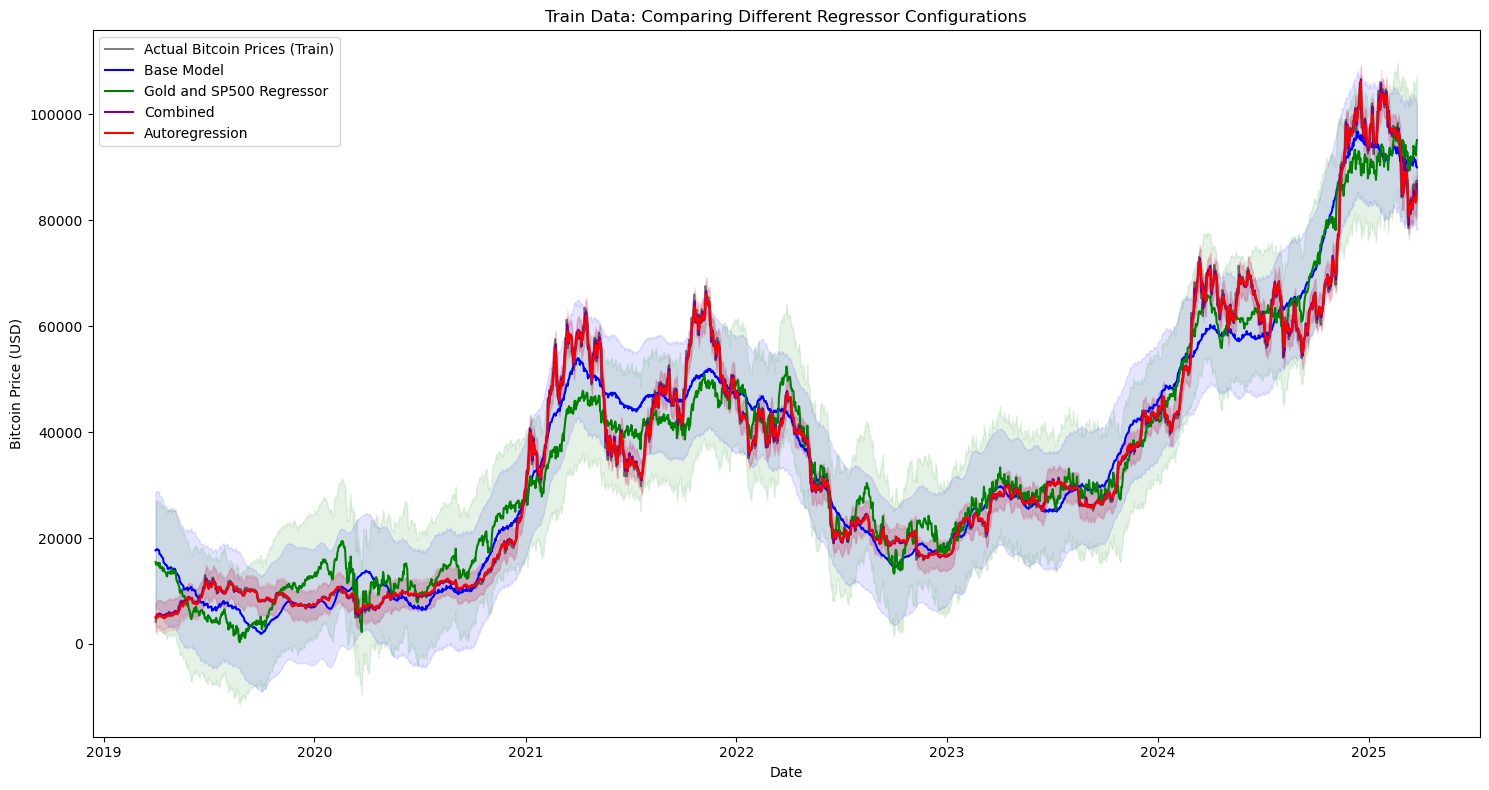

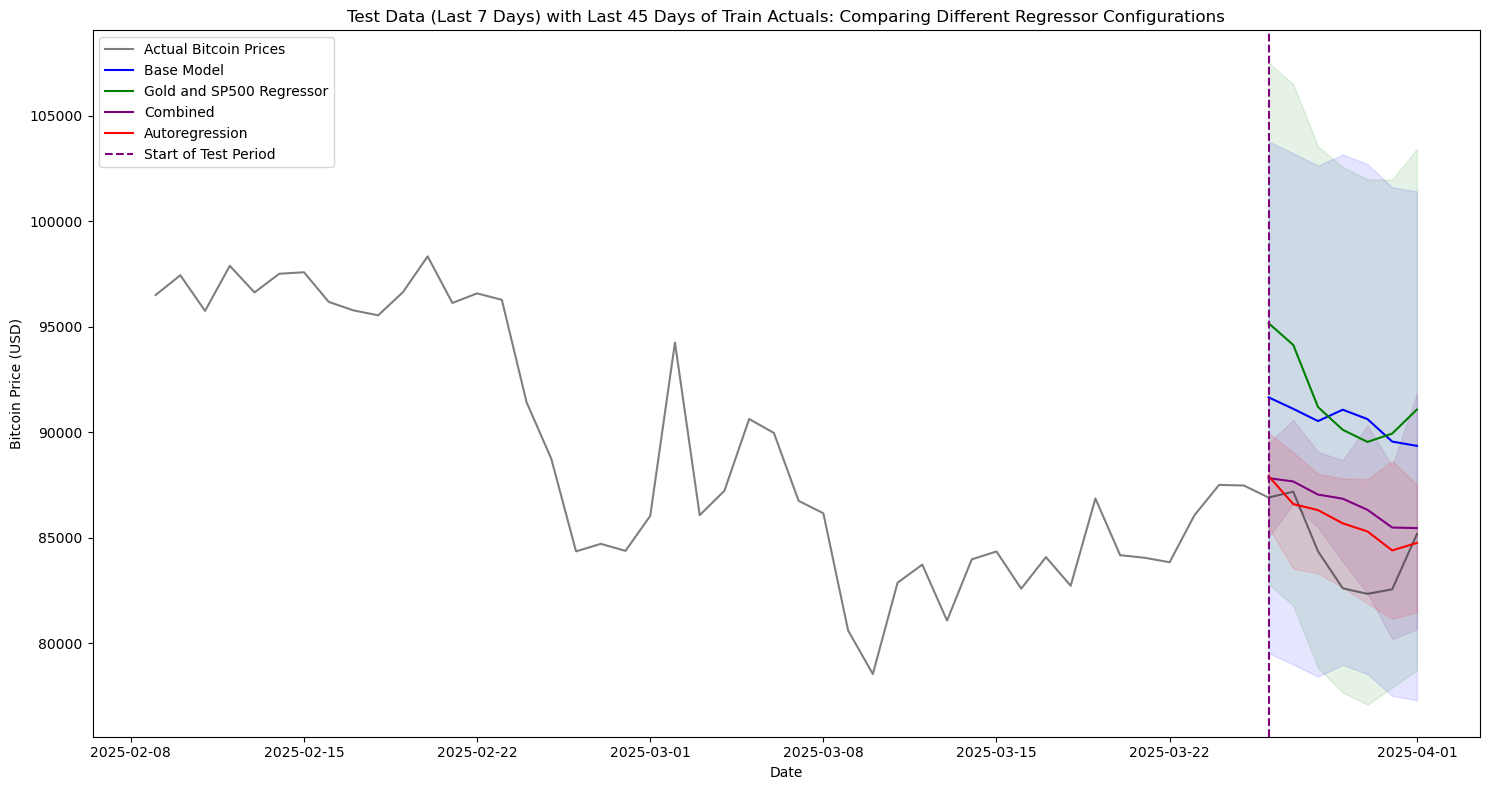


Model Performance Comparison (Train):
                                 MSPE      MAE   MAPE  Precision_error
Base Model                28618879.85  4094.83  18.59             0.05
Gold and SP500 Regressor  34291612.13  4616.11  22.00             0.06
Combined                   1630486.03   803.38   2.59             0.00
Autoregression             2033532.71   924.01   3.01             0.00

Model Performance Comparison (Test - Last 7 Days):
                                 MSPE      MAE  MAPE  Precision_error
Base Model                40420812.40  6112.36  7.29            11.10
Gold and SP500 Regressor  51605545.57  7152.64  8.47            14.17
Combined                   7268767.22  2219.28  2.67             2.00
Autoregression             3857989.61  1694.28  2.03             1.06


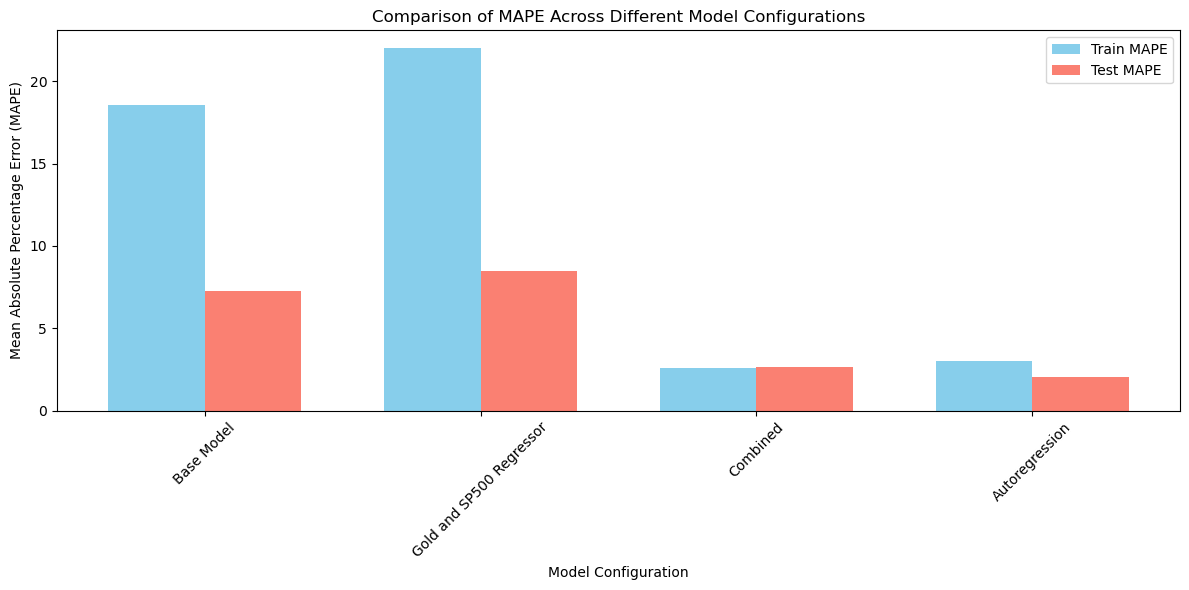

In [ ]:
# Define test splits
forecast_horizon = 7
test_start_date = df_comb["ts"].max() - pd.Timedelta(days=forecast_horizon - 1)
test = df_comb[df_comb["ts"] >= test_start_date].reset_index(drop=True)

# Get forecast DataFrames
forecast_dfs = {
    'Base Model': base_forecast_df,
    'Gold and SP500 Regressor': exog_regressor_forecast_df,
    'Combined': combined_regressors_forecast_df,
    'Autoregression': autoregression_forecast_df
}

# Merge forecasts with train and test data
train_forecasts = {}
test_forecasts = {}
for model_name, forecast_df in forecast_dfs.items():
    train_forecasts[model_name] = train.merge(
        forecast_df[['ts', 'forecast', 'forecast_lower', 'forecast_upper']],
        on='ts', how='left'
    )
    test_forecasts[model_name] = test.merge(
        forecast_df[['ts', 'forecast', 'forecast_lower', 'forecast_upper']],
        on='ts', how='left'
    )

# --- Plot Results for Train ---
plt.figure(figsize=(15, 8))
plt.plot(train['ts'], train['y'], label='Actual Bitcoin Prices (Train)', color='black', alpha=0.5)

colors = {'Base Model': 'blue', 'Gold and SP500 Regressor': 'green',
          'Combined': 'purple', 'Autoregression': 'red'}

for model_name, train_forecast in train_forecasts.items():
    plt.plot(train_forecast['ts'], train_forecast['forecast'],
             label=f'{model_name}', color=colors[model_name])
    plt.fill_between(train_forecast['ts'],
                     train_forecast['forecast_lower'],
                     train_forecast['forecast_upper'],
                     color=colors[model_name], alpha=0.1)

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Train Data: Comparing Different Regressor Configurations")
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Results for Test with Last 45 Days of Train Actuals ---
days_to_show_from_train = 45
plot_start = test_start_date - pd.Timedelta(days=days_to_show_from_train)

# Filter train data for the last 35 days
train_plot = train[train['ts'] >= plot_start]

# Combine train and test data for plotting actuals
plot_data = pd.concat([train_plot, test], ignore_index=True)

plt.figure(figsize=(15, 8))

# Plot actual prices for both train and test periods
plt.plot(plot_data['ts'], plot_data['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Plot forecasts for test period only
for model_name, test_forecast in test_forecasts.items():
    plt.plot(test_forecast['ts'], test_forecast['forecast'],
             label=f'{model_name}', color=colors[model_name])
    plt.fill_between(test_forecast['ts'],
                     test_forecast['forecast_lower'],
                     test_forecast['forecast_upper'],
                     color=colors[model_name], alpha=0.1)

# Add vertical line at the start of the test period
plt.axvline(x=test_start_date, color='purple', linestyle='--', label='Start of Test Period')

plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title(f"Test Data (Last 7 Days) with Last {days_to_show_from_train} Days of Train Actuals: Comparing Different Regressor Configurations")
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics for each model
metrics_data = {'Train': {}, 'Test': {}}
for model_name in forecast_dfs.keys():
    # Train metrics
    train_metrics = calculate_metrics(
        train_forecasts[model_name]['y'],
        train_forecasts[model_name]['forecast']
    )
    metrics_data['Train'][model_name] = train_metrics

    # Test metrics
    test_metrics = calculate_metrics(
        test_forecasts[model_name]['y'],
        test_forecasts[model_name]['forecast']
    )
    metrics_data['Test'][model_name] = test_metrics

# Create metrics comparison DataFrames
train_metrics_df = pd.DataFrame.from_dict(metrics_data['Train'], orient='index')
test_metrics_df = pd.DataFrame.from_dict(metrics_data['Test'], orient='index')

# Display metrics
print("\nModel Performance Comparison (Train):")
print(train_metrics_df.round(2))
print("\nModel Performance Comparison (Test - Last 7 Days):")
print(test_metrics_df.round(2))

# --- Bar Chart Comparing MAPE ---
plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(forecast_dfs))

plt.bar([i - bar_width/2 for i in index],
        [metrics_data['Train'][model]['MAPE'] for model in forecast_dfs.keys()],
        bar_width, label='Train MAPE', color='skyblue')

plt.bar([i + bar_width/2 for i in index],
        [metrics_data['Test'][model]['MAPE'] for model in forecast_dfs.keys()],
        bar_width, label='Test MAPE', color='salmon')

plt.xlabel('Model Configuration')
plt.ylabel('Mean Absolute Percentage Error (MAPE)')
plt.title('Comparison of MAPE Across Different Model Configurations')
plt.xticks(index, forecast_dfs.keys(), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


As can be seen from the prediction accuracy metrics, the model with autoregression performs better as compared to the other models, inlcuding the  one that has Gold and S&P500 as regressors.

## Analysing the Effect of Holidays

In the Silverkite model, holidays are treated as events that may cause deviations in the time series (e.g., spikes or drops in S&P 500 prices around market holidays). The model creates indicator variables (dummy variables) for holidays and their surrounding days to capture these effects. The events dictionary allows you to:

* Specify which countries' holidays to include (e.g., US holidays).
* Define the number of days before and after each holiday to model as affected periods.

More details can be found here - https://linkedin.github.io/greykite/docs/0.1.0/html/pages/model_components/0400_events.html

Some of the hyperparameters used in the code are as follows:
1. holiday_lookup_countries - Specifies the country (or countries) whose holidays should be included in the model.
2. holiday_pre_num_days - Specifies the number of days before each holiday to include as affected periods.
3. holiday_post_num_days - Specifies the number of days after each holiday to include as affected periods.

**Experiment Details-** In the analysis below, we are considering the model with autoregressive lags while also adding the holiday related hyperparameters and doing the grid search across combinations of those parameters. The hyperparameters considered are holiday_pre_num_days and holiday_post_num_days. We also consider all US holidays in this analysis.

In [ ]:
autoregression_config_h = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": selected_trend},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "7D"
            },
            "seasonality_changepoints_dict": dict(
            potential_changepoint_distance="30D",
            seasonality_components_df=pd.DataFrame({
            "name": ["tow", "conti_year"],
            "period": [7.0, 1.0],
            "order": [4, 6],
            "seas_names": ["weekly", "yearly"]})
        )},
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": ['US'], "holiday_pre_num_days":[2,3,4], "holiday_post_num_days":[2,3,4]},
        autoregression={"autoreg_dict": {"lag_dict": {"orders": lag_days}}},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

autoregression_result_h = forecaster.run_forecast_config(df=df_combined_cp, config=autoregression_config_h)
autoregression_forecast_df_h = autoregression_result_h.forecast.df

Fitting 3 folds for each of 9 candidates, totalling 27 fits


In [ ]:
cv_results = summarize_grid_search_results(
     grid_search=autoregression_result_h.grid_search,
     decimals=1,
     cv_report_metrics=None,
     column_order=["rank", "params", "mean_test", "split_test", "mean_train", "split_train", "mean_fit_time", "mean_score_time"])
cv_results["params"] = cv_results["params"].astype(str)
cv_results.set_index("params", drop=True, inplace=True)
cv_results

,rank_test_MAPE,param_estimator__auto_holiday_params,mean_test_MAPE,split_test_MAPE,mean_train_MAPE,split_train_MAPE,mean_fit_time,mean_score_time
params,,,,,,,,
"[('estimator__holiday_pre_num_days', 2), ('estimator__holiday_post_num_days', 2)]",3,None,3.9,"(3.4, 5.9, 2.5)",3.0,"(2.3, 3.5, 3.1)",73.4,46.4
"[('estimator__holiday_pre_num_days', 3), ('estimator__holiday_post_num_days', 2)]",2,None,3.5,"(2.4, 5.3, 2.8)",2.9,"(2.2, 3.5, 3.1)",69.8,45.1
"[('estimator__holiday_pre_num_days', 4), ('estimator__holiday_post_num_days', 2)]",6,None,4.4,"(5.8, 5.7, 1.7)",2.9,"(2.1, 3.5, 3.1)",65.5,40.4
"[('estimator__holiday_pre_num_days', 2), ('estimator__holiday_post_num_days', 3)]",1,None,3.5,"(3.3, 5.8, 1.3)",3.0,"(2.3, 3.5, 3.1)",45.2,27.5
"[('estimator__holiday_pre_num_days', 3), ('estimator__holiday_post_num_days', 3)]",7,None,4.4,"(5.6, 6.0, 1.6)",2.9,"(2.1, 3.5, 3.1)",41.4,26.1
"[('estimator__holiday_pre_num_days', 4), ('estimator__holiday_post_num_days', 3)]",5,None,4.2,"(4.4, 6.2, 2.0)",2.9,"(2.0, 3.5, 3.1)",67.1,39.9
"[('estimator__holiday_pre_num_days', 2), ('estimator__holiday_post_num_days', 4)]",8,None,4.6,"(5.8, 6.2, 1.7)",3.0,"(2.2, 3.5, 3.1)",64.9,40.8
"[('estimator__holiday_pre_num_days', 3), ('estimator__holiday_post_num_days', 4)]",4,None,4.2,"(4.0, 5.5, 3.0)",2.9,"(2.1, 3.5, 3.1)",64.6,38.3
"[('estimator__holiday_pre_num_days', 4), ('estimator__holiday_post_num_days', 4)]",9,None,5.5,"(8.5, 5.9, 2.1)",2.9,"(2.0, 3.5, 3.1)",5837.2,11888.5


**Analysis Insights:** From the output above, the combination holiday_pre_num_days =3 and holiday_post_num_days=3 has the lowest test MAPE. We will thus continue with these parameters for the further analysis.

# Comparison: Prophet Model versus Silverkite Model

**Experiment Details-**

Here, in this experiment, we are comparing prophet model with the silverkite model. In this implementation, the silverkite model will  include the autoregressive lags. The prophet model will not include any additional regressors.

*Note*: *In this section, We have not used holiday component for the prophet model. Hence, for this section, the silverkite model also does not use holidays.*

In [ ]:
# Split data for training and testing
end_date = df_comb['ts'].max()
train_end_date = end_date - pd.Timedelta(days=forecast_horizon)
train_df = df_comb[df_comb['ts'] <= train_end_date].copy()
test_df = df_comb[df_comb['ts'] > train_end_date].copy()

# Prophet model with custom change points, without holidays, without seasonality
changepoints = ['2020-03-12', '2020-12-16', '2021-05-19', '2021-11-10',
                '2022-05-09', '2022-11-11', '2023-03-13', '2024-12-05']
prophet_train = train_df[['ts', 'y']].rename(columns={'ts': 'ds'})
m = Prophet(
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoints=changepoints
).add_seasonality(name='monthly', period=30.5, fourier_order=5)
m.fit(prophet_train)
future = m.make_future_dataframe(periods=7)
prophet_forecast = m.predict(future)

silverkite_config = ForecastConfig(
    model_template="SILVERKITE",
    forecast_horizon=7,
    coverage=0.95,
    metadata_param=MetadataParam(time_col="ts", value_col="y", freq="D"),
    model_components_param=ModelComponentsParam(
        growth={"growth_term": "quadratic"},
        changepoints={"changepoints_dict": {
                "method": "auto",
                "regularization_strength": 0.5,
                "no_changepoint_proportion_from_end": 0.0,
                "potential_changepoint_n": 20,
                "resample_freq": "7D"
            },
            "seasonality_changepoints_dict": dict(
            potential_changepoint_distance="30D",
            seasonality_components_df=pd.DataFrame({
            "name": ["tow", "conti_year"],
            "period": [7.0, 1.0],
            "order": [4, 6],
            "seas_names": ["weekly", "yearly"]})
        )},
        seasonality={
            "yearly_seasonality": True,
            "quarterly_seasonality": False,
            "monthly_seasonality": False,
            "weekly_seasonality": False,
            "daily_seasonality": False,
        },
        events={"holiday_lookup_countries": None, "holidays_to_model_separately": None},
        autoregression={"autoreg_dict": {"lag_dict": {"orders": lag_days}}},
        uncertainty={"uncertainty_dict": {"uncertainty_method": "simple_conditional_residuals"}},
        custom={
            "feature_sets_enabled": True,
            "extra_pred_cols": [],
            "fit_algorithm_dict": {"fit_algorithm": "ridge"}
        }
    )
)

train_df_silverkite = train_df.copy()
forecaster = Forecaster()
silverkite_result = forecaster.run_forecast_config(df=df_combined_cp, config=silverkite_config)
silverkite_forecast_df = silverkite_result.forecast.df


2025-06-18 15:25:10 cmdstanpy [DEBUG]: cmd: where.exe tbb.dll
cwd: None
2025-06-18 15:25:10 cmdstanpy [DEBUG]: TBB already found in load path
2025-06-18 15:25:10 prophet [INFO]: Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
2025-06-18 15:25:11 cmdstanpy [DEBUG]: input tempfile: C:\Users\ns109\AppData\Local\Temp\tmpveyho7ne\oheyg_gj.json
2025-06-18 15:25:11 cmdstanpy [DEBUG]: input tempfile: C:\Users\ns109\AppData\Local\Temp\tmpveyho7ne\npi43deb.json
2025-06-18 15:25:11 cmdstanpy [DEBUG]: idx 0
2025-06-18 15:25:11 cmdstanpy [DEBUG]: running CmdStan, num_threads: None
2025-06-18 15:25:11 cmdstanpy [DEBUG]: CmdStan args: ['C:\\Users\\ns109\\AppData\\Local\\anaconda\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=61846', 'data', 'file=C:\\Users\\ns109\\AppData\\Local\\Temp\\tmpveyho7ne\\oheyg_gj.json', 'init=C:\\Users\\ns109\\AppData\\Local\\Temp\\tmpveyho7ne\\npi43deb.json', 'output', 'file=C:\\Users\\ns109\\AppData\\L

15:25:11 - cmdstanpy - INFO - Chain [1] start processing


2025-06-18 15:25:11 cmdstanpy [INFO]: Chain [1] start processing


15:25:11 - cmdstanpy - INFO - Chain [1] done processing


2025-06-18 15:25:11 cmdstanpy [INFO]: Chain [1] done processing


...

2025-06-18 15:25:11 cmdstanpy [ERROR]: Chain [1] error: error during processing Operation not permitted
2025-06-18 15:25:11 prophet.models [WARNING]: Optimization terminated abnormally. Falling back to Newton.
2025-06-18 15:25:11 cmdstanpy [DEBUG]: input tempfile: C:\Users\ns109\AppData\Local\Temp\tmpveyho7ne\6eq2tg2u.json
2025-06-18 15:25:11 cmdstanpy [DEBUG]: input tempfile: C:\Users\ns109\AppData\Local\Temp\tmpveyho7ne\urf5sd7j.json
2025-06-18 15:25:11 cmdstanpy [DEBUG]: idx 0
2025-06-18 15:25:11 cmdstanpy [DEBUG]: running CmdStan, num_threads: None
2025-06-18 15:25:11 cmdstanpy [DEBUG]: CmdStan args: ['C:\\Users\\ns109\\AppData\\Local\\anaconda\\Lib\\site-packages\\prophet\\stan_model\\prophet_model.bin', 'random', 'seed=70835', 'data', 'file=C:\\Users\\ns109\\AppData\\Local\\Temp\\tmpveyho7ne\\6eq2tg2u.json', 'init=C:\\Users\\ns109\\AppData\\Local\\Temp\\tmpveyho7ne\\urf5sd7j.json', 'output', 'file=C:\\Users\\ns109\\AppData\\Local\\Temp\\tmpveyho7ne\\prophet_modell3fvi9r_\\prophet

15:25:11 - cmdstanpy - INFO - Chain [1] start processing


2025-06-18 15:25:11 cmdstanpy [INFO]: Chain [1] start processing


15:25:13 - cmdstanpy - INFO - Chain [1] done processing


2025-06-18 15:25:13 cmdstanpy [INFO]: Chain [1] done processing
Fitting 3 folds for each of 1 candidates, totalling 3 fits


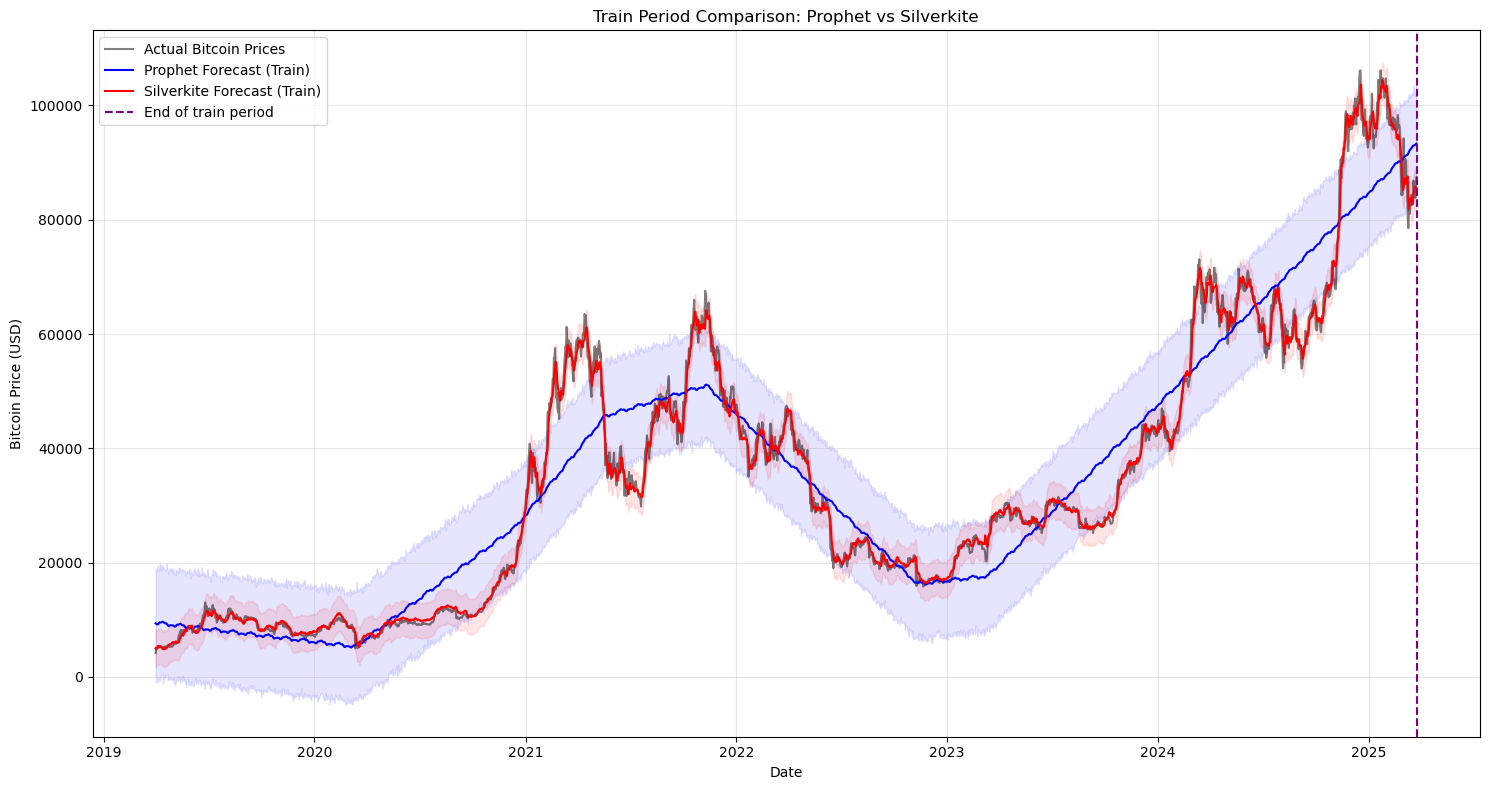

In [ ]:
# Define plotting window: last year days of train + test
days_to_show_from_train = train_df.shape[0]
plot_start = train_end_date - pd.Timedelta(days=days_to_show_from_train)

# Filter data for plotting
plot_df = df_combined_cp[df_combined_cp['ts'] >= plot_start]
prophet_plot_forecast = prophet_forecast[prophet_forecast['ds'] >= plot_start]
silverkite_plot_forecast = silverkite_forecast_df[silverkite_forecast_df['ts'] >= plot_start]


# Fitted Values Plot
plt.figure(figsize=(15, 8))
plt.plot(plot_df['ts'], plot_df['y'], label='Actual Bitcoin Prices', color='black', alpha=0.5)

# Prophet forecast (train period)
plt.plot(prophet_plot_forecast['ds'][prophet_plot_forecast['ds'] < train_end_date],
         prophet_plot_forecast['yhat'][prophet_plot_forecast['ds'] < train_end_date],
         label='Prophet Forecast (Train)', color='blue', linewidth=1.5)
plt.fill_between(prophet_plot_forecast['ds'][prophet_plot_forecast['ds'] < train_end_date],
                 prophet_plot_forecast['yhat_lower'][prophet_plot_forecast['ds'] < train_end_date],
                 prophet_plot_forecast['yhat_upper'][prophet_plot_forecast['ds'] < train_end_date],
                 color='blue', alpha=0.1)

# Silverkite forecast (train period)
plt.plot(silverkite_plot_forecast['ts'][silverkite_plot_forecast['ts'] < train_end_date],
         silverkite_plot_forecast['forecast'][silverkite_plot_forecast['ts'] < train_end_date],
         label='Silverkite Forecast (Train)', color='red', linewidth=1.5)
plt.fill_between(silverkite_plot_forecast['ts'][silverkite_plot_forecast['ts'] < train_end_date],
                 silverkite_plot_forecast['forecast_lower'][silverkite_plot_forecast['ts'] < train_end_date],
                 silverkite_plot_forecast['forecast_upper'][silverkite_plot_forecast['ts'] < train_end_date],
                 color='red', alpha=0.1)

plt.axvline(x=train_end_date, color='purple', linestyle='--', label='End of train period')
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Train Period Comparison: Prophet vs Silverkite")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


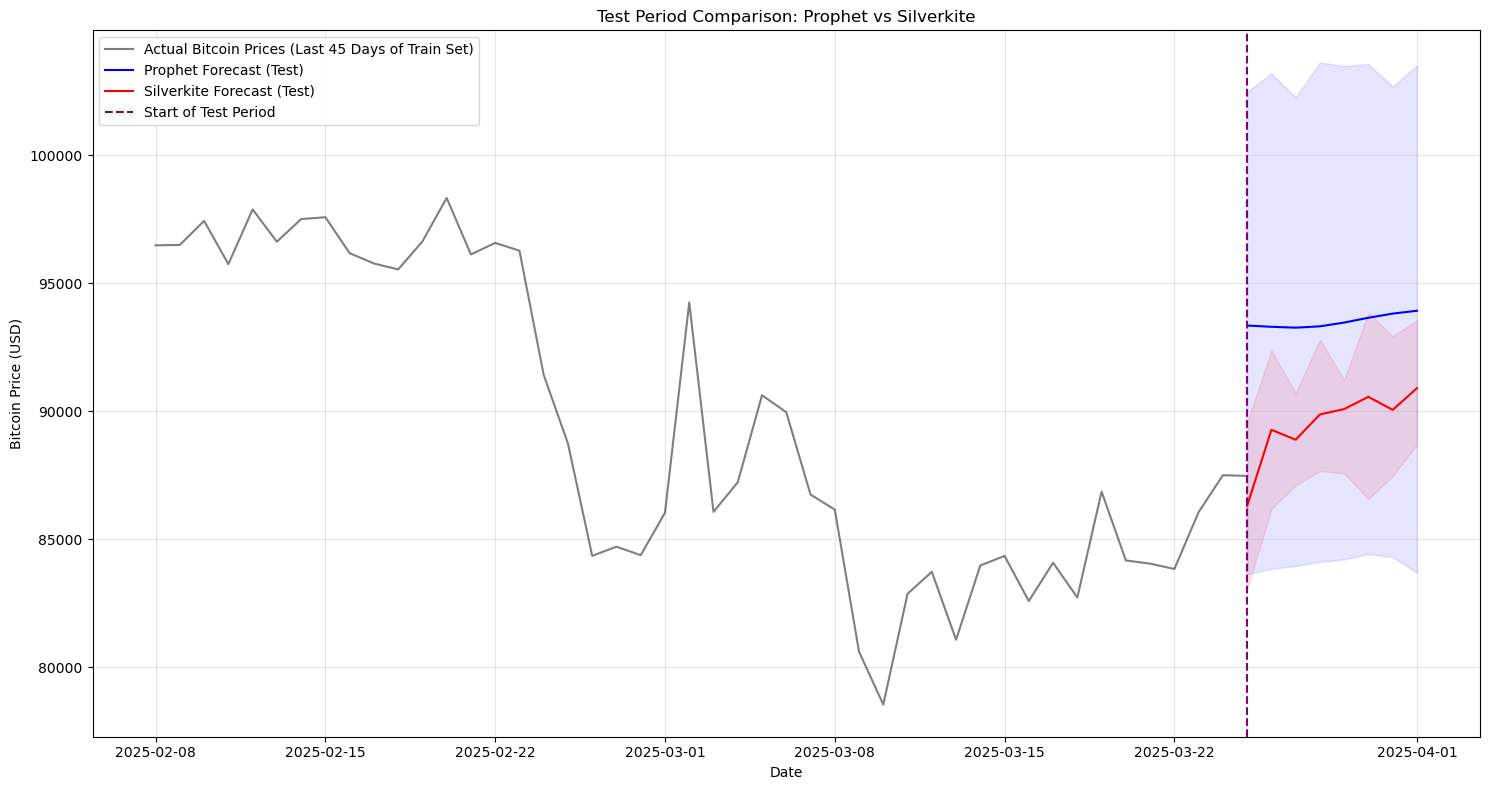

In [ ]:
# Prediction Comparison Plot
plt.figure(figsize=(15, 8))

# Only plot the last 45 days of the actual data in the training period
plot_actual_df = plot_df[
    (plot_df['ts'] <= train_end_date) &
    (plot_df['ts'] >= train_end_date - pd.Timedelta(days=45))
]

plt.plot(
    plot_actual_df['ts'],
    plot_actual_df['y'],
    label='Actual Bitcoin Prices (Last 45 Days of Train Set)',
    color='black', alpha=0.5
)

# Prophet forecast (test period)
plt.plot(
    prophet_plot_forecast['ds'][prophet_plot_forecast['ds'] >= train_end_date],
    prophet_plot_forecast['yhat'][prophet_plot_forecast['ds'] >= train_end_date],
    label='Prophet Forecast (Test)', color='blue', linewidth=1.5
)
plt.fill_between(
    prophet_plot_forecast['ds'][prophet_plot_forecast['ds'] >= train_end_date],
    prophet_plot_forecast['yhat_lower'][prophet_plot_forecast['ds'] >= train_end_date],
    prophet_plot_forecast['yhat_upper'][prophet_plot_forecast['ds'] >= train_end_date],
    color='blue', alpha=0.1
)

# Silverkite forecast (test period)
plt.plot(
    silverkite_plot_forecast['ts'][silverkite_plot_forecast['ts'] >= train_end_date],
    silverkite_plot_forecast['forecast'][silverkite_plot_forecast['ts'] >= train_end_date],
    label='Silverkite Forecast (Test)', color='red', linewidth=1.5
)
plt.fill_between(
    silverkite_plot_forecast['ts'][silverkite_plot_forecast['ts'] >= train_end_date],
    silverkite_plot_forecast['forecast_lower'][silverkite_plot_forecast['ts'] >= train_end_date],
    silverkite_plot_forecast['forecast_upper'][silverkite_plot_forecast['ts'] >= train_end_date],
    color='red', alpha=0.1
)

# Mark the start of the test period
plt.axvline(x=train_end_date, color='purple', linestyle='--', label='Start of Test Period')

# Plot labels and title
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Test Period Comparison: Prophet vs Silverkite")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
test_merged_prophet = test_df.merge(prophet_forecast[['ds', 'yhat']], left_on='ts', right_on='ds', how='left')
test_merged_silverkite = test_df.merge(silverkite_forecast_df[['ts', 'forecast']], left_on='ts', right_on='ts', how='left')

metrics_prophet = calculate_metrics(test_merged_prophet['y'], test_merged_prophet['yhat'])
metrics_silverkite = calculate_metrics(test_merged_silverkite['y'], test_merged_silverkite['forecast'])

print(f"\nProphet MAPE on Test: {metrics_prophet['MAPE']:.2f}%")
print(f"Prophet MAE on Test: {metrics_prophet['MAE']:.2f}")
print(f"Prophet MSPE on Test: {metrics_prophet['MSPE']:.2f}")
print(f"Prophet Precision on Test: {metrics_prophet['Precision_error']:.2f}")

print(f"\nSilverkite MAPE on Test: {metrics_silverkite['MAPE']:.2f}%")
print(f"Silverkite MAE on Test: {metrics_silverkite['MAE']:.2f}")
print(f"Silverkite MSPE on Test: {metrics_silverkite['MSPE']:.2f}")
print(f"Silverkite Precision on Test: {metrics_silverkite['Precision_error']:.2f}")



Prophet MAPE on Test: 10.83%
Prophet MAE on Test: 9093.23
Prophet MSPE on Test: 86863809.89
Prophet Precision on Test: 23.85

Silverkite MAPE on Test: 6.59%
Silverkite MAE on Test: 5506.38
Silverkite MSPE on Test: 35977373.38
Silverkite Precision on Test: 9.88
